## Importación de paquetes
___
___

In [272]:
import os
import numpy as np                  # Importación de la biblioteca numpy para el manejo de arreglos
import pandas as pd                 # Importación de la biblioteca pandas para el manejo de datos contenidos en una base de datos
import matplotlib.pyplot as plt     # Importación de la biblioteca para realizar la visualización de resultados mediante elementos gráficos
import seaborn as sns               # Importación de la biblioteca para realizar la visualización de resultados mediante elementos gráficos
np.set_printoptions(
    suppress=True,
    linewidth=100,
    precision=2
)
plt.rcParams['figure.dpi'] = 120

## Funciones Auxiliares
___
___

### Categorización datos crudos

---
---

Esta función tiene como finalidad realizar una **categorización y transformación de datos crudos hacia una representación numérica**, sustituyendo aquellos valores no convertibles por valores faltantes (`NaN`). Su objetivo principal es preparar datos originalmente heterogéneos (por ejemplo, cadenas de texto o mezclas de tipos) para su posterior análisis numérico.

La función construye una estructura matricial homogénea en formato `numpy.ndarray`.

---

🔵 **Parámetros de entrada**

Para su correcta ejecución, la función requiere el siguiente parámetro:

- `datos`: estructura iterable bidimensional (por ejemplo, lista de listas), donde cada elemento interno representa una fila de datos que puede contener valores numéricos o no numéricos.

---

🟠 **Proceso de la función**

Durante su ejecución, la función realiza las siguientes operaciones:

- Recorre cada fila del conjunto de datos de entrada.
- Intenta convertir cada elemento a tipo numérico (`float`).
- En caso de fallo en la conversión, asigna el valor `NaN` (`np.nan`).
- Construye una nueva estructura con los valores numéricos o faltantes.
- Convierte la lista resultante en un arreglo de `NumPy` para optimizar su manejo.

---

🟢 **Salida de la función**

La función genera dos salidas:

- **Efecto en consola:** impresión de las primeras 5 columnas del arreglo resultante (`datos_numericos[:, :5]`), lo que permite una inspección rápida de la transformación.
- **Retorno:** un arreglo `numpy.ndarray` con los datos convertidos a formato numérico, donde los valores no convertibles han sido reemplazados por `NaN`.

---

---
---

In [273]:
def categorizacion_datos_crudos(datos):
    datos_numericos = []
    for i in datos:
        temporal = []
        for j in i:
            try:
                x = float(j)
            except:
                x = np.nan
            finally:
                temporal.append(x)
        datos_numericos.append(temporal)
    datos_numericos = np.array(datos_numericos)
    print(datos_numericos[:,:5])
    return datos_numericos

### Obtención de Porcentaje de Valores Nulos en un Conjunto de Datos

---
---

Esta función tiene como finalidad calcular el **porcentaje de valores nulos por columna en un conjunto de datos estructurado como arreglo de NumPy**, y organizar dicha información en un formato tabular que facilite su análisis y priorización durante el proceso de limpieza de datos.

Su objetivo principal es identificar variables con alta presencia de valores faltantes, lo cual es clave en etapas de **preprocesamiento, imputación y control de calidad de datos**.

---

🔵 **Parámetros de entrada**

Para su correcta ejecución, la función requiere los siguientes parámetros:

- `datos`: arreglo de tipo `numpy.ndarray` donde cada elemento representa una columna del conjunto de datos.

- `etiquetas`: lista de cadenas de caracteres que contiene los nombres o etiquetas asociadas a cada columna del arreglo.

---

🟠 **Proceso de la función**

Durante su ejecución, la función realiza las siguientes operaciones:

- Itera sobre cada columna del arreglo de entrada.
- Calcula el porcentaje de valores nulos utilizando `pd.isna()`:
  - Cuenta los valores faltantes en la columna.
  - Divide entre el total de elementos.
  - Multiplica por 100 para obtener el porcentaje.
- Construye un `DataFrame` con dos columnas:
  - `Categoria`: nombre de la variable.
  - `Porcentaje`: porcentaje de valores nulos.
- Ordena el `DataFrame` de forma descendente según el porcentaje de valores nulos.
- Muestra en consola las primeras filas del resultado no ordenado.

---

🟢 **Salida de la función**

La función retorna dos estructuras:

- `categoria_pandas`: DataFrame original con el porcentaje de valores nulos por variable.
- `categoria_pandas_ordenado`: DataFrame ordenado de mayor a menor según el porcentaje de valores nulos.

Adicionalmente, imprime en consola una vista parcial del DataFrame original para inspección rápida.

---

---
---

In [274]:
def proporcion_datos_nulos_numpy(datos, etiquetas):
    porcentaje_datos_nulos = []
    for columna in datos:
        porcentaje_datos_nulos.append(
            pd.isna(columna).sum() / len(columna) * 100
        )
    categoria_pandas = pd.DataFrame({
        'Categoria': etiquetas,
        'Porcentaje': porcentaje_datos_nulos
    })
    categoria_pandas_ordenado = categoria_pandas.sort_values(
        by='Porcentaje',
        ascending=False
    )
    print(categoria_pandas.head())
    return (categoria_pandas, categoria_pandas_ordenado)

---
---

Esta función tiene como finalidad calcular el **porcentaje de completitud (o falta de datos) por variable** dentro de un conjunto de datos estructurado en un `DataFrame` de pandas. Su objetivo principal es evaluar la calidad de los datos a nivel de columnas, identificando aquellas variables con mayor presencia de valores ausentes.

Este tipo de análisis es fundamental en etapas de **perfilamiento de datos, limpieza y preprocesamiento**, ya que permite priorizar estrategias de imputación o eliminación de variables según su nivel de completitud.

---

🔵 **Parámetros de entrada**

Para su correcta ejecución, la función requiere los siguientes parámetros:

- `datos`: `DataFrame` de pandas que contiene el conjunto de datos a analizar.

- `etiquetas`: lista de cadenas de caracteres que representa los nombres de las variables sobre las cuales se calculará la completitud.

---

🟠 **Proceso de la función**

Durante su ejecución, la función realiza las siguientes operaciones:

- Selecciona las columnas especificadas en `etiquetas` dentro del `DataFrame`.
- Calcula el porcentaje de valores nulos por variable mediante:
  - `isna().mean()` para obtener la proporción de valores faltantes.
  - Multiplicación por 100 para expresar el resultado en porcentaje.
- Construye un `DataFrame` con:
  - `Categoria`: nombre de la variable.
  - `Porcentaje`: porcentaje de valores nulos.
- Ordena el `DataFrame` de forma descendente según el porcentaje de valores faltantes.
- Imprime el `DataFrame` generado sin ordenar.

---

🟢 **Salida de la función**

La función retorna dos estructuras:

- `categoria_pandas`: `DataFrame` con el porcentaje de valores nulos por variable.
- `categoria_pandas_ordenado`: `DataFrame` ordenado de mayor a menor según el porcentaje de valores nulos.

Adicionalmente, imprime en consola el `DataFrame` sin ordenar para inspección rápida.

---

---
---

In [275]:
def completitud_variables_datos(datos, etiquetas):
    
    categoria_pandas = pd.DataFrame({'Categoria': etiquetas, 'Porcentaje': datos[etiquetas].isna().mean() * 100}).reset_index(drop=True)

    categoria_pandas_ordenado = categoria_pandas.sort_values(by='Porcentaje', ascending=False)

    print(categoria_pandas)

    return (categoria_pandas, categoria_pandas_ordenado)

---
---

Esta función tiene como finalidad analizar la **completitud de los registros (filas)** dentro de un conjunto de datos, evaluando la cantidad de valores nulos presentes en cada observación. Su objetivo principal es caracterizar la **distribución de valores faltantes a nivel de registro**, lo cual permite identificar la proporción de filas completamente completas o parcialmente incompletas.

Este análisis es útil en etapas de **calidad de datos, depuración y selección de registros válidos**, ya que permite tomar decisiones sobre la eliminación o imputación de filas con alto grado de ausencia de información.

---

🔵 **Parámetros de entrada**

Para su correcta ejecución, la función requiere el siguiente parámetro:

- `datos`: `DataFrame` de pandas que contiene el conjunto de datos a analizar.

---

🟠 **Proceso de la función**

Durante su ejecución, la función realiza las siguientes operaciones:

- Calcula el número de valores nulos por fila utilizando `isna().sum(axis=1)`.
- Obtiene la distribución de estas cantidades mediante `value_counts(normalize=True)`, lo que permite expresar la frecuencia relativa de cada nivel de nulos.
- Convierte el resultado en un `DataFrame` con dos columnas:
  - `Cantidad_nulos`: número de valores faltantes por registro.
  - `Porcentaje`: proporción de registros que presentan esa cantidad de nulos.
- Convierte la proporción a porcentaje multiplicando por 100.
- Ordena el `DataFrame` de forma ascendente según la cantidad de valores nulos.
- Imprime la tabla resultante en consola.

---

🟢 **Salida de la función**

La función retorna un `DataFrame` con la distribución de la completitud de los registros, donde cada fila representa:

- El número de valores nulos presentes en un registro.
- El porcentaje de registros que presentan dicha cantidad de valores faltantes.

---

---
---

In [276]:
def completitud_registros_datos(datos):

    distribucion_nulos = (datos.isna().sum(axis=1).value_counts(normalize=True).reset_index())

    distribucion_nulos.columns = ['Cantidad_nulos', 'Porcentaje']

    distribucion_nulos['Porcentaje'] *= 100

    distribucion_nulos = distribucion_nulos.sort_values(
        by='Cantidad_nulos',
        ascending=True
    )

    print(distribucion_nulos)

    return distribucion_nulos

### Clasificacion de Variables

---
---

Esta función tiene como finalidad realizar una **clasificación básica de variables dentro de un conjunto de datos**, separándolas en dos grupos según su nivel de completitud y su inclusión en una lista de excepciones. Su objetivo principal es apoyar el proceso de **identificación preliminar de variables numéricas y no numéricas (o categóricas/identificadoras)** para etapas posteriores de análisis o preprocesamiento.

---

🔵 **Parámetros de entrada**

Para su correcta ejecución, la función requiere los siguientes parámetros:

- `porcentajes`: lista o arreglo numérico que contiene el porcentaje de valores nulos o una métrica asociada a la completitud de cada variable.

- `etiquetas`: lista de cadenas de caracteres que representa los nombres de las variables del conjunto de datos.

- `excepciones`: lista opcional de variables que deben ser excluidas de la clasificación numérica. Por defecto es `None`.

---

🟠 **Proceso de la función**

Durante su ejecución, la función realiza las siguientes operaciones:

- Inicializa dos listas vacías:
  - `indice_numericos`: para variables consideradas numéricas.
  - `indice_no_numericos`: para variables consideradas no numéricas o excluidas.
- Recorre cada variable evaluando dos condiciones:
  - La variable no debe estar en la lista de excepciones.
  - El porcentaje asociado debe ser diferente de 100 (es decir, no completamente vacío o inválido).
- Clasifica los índices de las variables en función de estas condiciones.
- Imprime en consola las listas de índices correspondientes a cada grupo.

---

🟢 **Salida de la función**

La función retorna dos estructuras:

- `indice_numericos`: lista de índices asociados a variables consideradas numéricas.
- `indice_no_numericos`: lista de índices asociados a variables categóricas o excluidas del análisis numérico.

Adicionalmente, imprime ambas listas en consola para inspección directa.

---

---
---

In [277]:
def clasificacion_variables(porcentajes, etiquetas, excepciones=None):
    if excepciones is None:
        excepciones = []
    indice_numericos, indice_no_numericos = [], []
    for i in range(len(porcentajes)):
        if (etiquetas[i] not in excepciones) and (porcentajes[i] != 100):
            indice_numericos.append(i)
        else:
            indice_no_numericos.append(i)
    print(f'Lista de índices correspondientes a variables numéricas: {indice_numericos}')
    print(f'Lista de índices correspondientes a variables categóricas: {indice_no_numericos}')
    return (indice_numericos, indice_no_numericos)

### Extracción de Columnas por Categorías

---
---

Esta función tiene como finalidad realizar la **extracción de nombres de variables (columnas)** a partir de una lista de índices, utilizando como referencia un conjunto de etiquetas previamente definido. Su objetivo principal es facilitar la **selección de subconjuntos de variables dentro de un conjunto de datos**, a partir de una clasificación previa realizada mediante sus posiciones.

Este procedimiento es útil en flujos de trabajo de **preprocesamiento de datos**, donde las variables suelen ser clasificadas previamente mediante índices y posteriormente convertidas a sus nombres originales para su manipulación en estructuras como `DataFrame`.

---

🔵 **Parámetros de entrada**

Para su correcta ejecución, la función requiere los siguientes parámetros:

- `indices`: lista de enteros que representa las posiciones de las variables que se desean extraer.

- `etiquetas`: lista de cadenas de caracteres que contiene los nombres de todas las variables del conjunto de datos.

- `categoria`: cadena de caracteres utilizada como etiqueta descriptiva para identificar el grupo de variables que se está extrayendo (se imprime en consola como encabezado informativo).

---

🟠 **Proceso de la función**

Durante su ejecución, la función realiza las siguientes operaciones:

- Imprime en consola la categoría o grupo de variables que se está procesando.
- Recorre la lista de índices proporcionada.
- Para cada índice, obtiene la etiqueta correspondiente desde la lista `etiquetas`.
- Imprime cada variable seleccionada en consola como parte del seguimiento del proceso.
- Almacena los nombres de las variables en una lista.

---

🟢 **Salida de la función**

La función retorna:

- `columnas`: lista de cadenas de caracteres que contiene los nombres de las variables correspondientes a los índices proporcionados.

Adicionalmente, genera una salida en consola con:
- El nombre de la categoría.
- Las variables seleccionadas una por una.

---

---
---

In [278]:
def extraccion_columnas(indices, etiquetas, categoria):
    print(categoria)
    columnas = []
    for i in indices:
        columnas.append(etiquetas[i])
        print(etiquetas[i])
    return columnas

### Generación de Gráfico de Barra

---
---

Esta función tiene como finalidad generar un **gráfico de barras personalizado** a partir de un conjunto de datos tabular, utilizando las librerías `seaborn` y `matplotlib`. Su objetivo principal es facilitar la visualización de distribuciones o relaciones entre dos variables, permitiendo una configuración flexible de orientación, tamaño y estilo del gráfico.

La función está diseñada para producir gráficos con una estética consistente, incorporando elementos como etiquetas en las barras, cuadrículas, rotación de ejes y personalización de títulos y dimensiones.

---

🔵 **Parámetros de entrada**

Para su correcta ejecución, la función requiere los siguientes parámetros:

- `datos`: DataFrame que contiene los datos a visualizar.

- `columnas`: lista de dos elementos que define las variables a utilizar en el gráfico:
  - `columnas[0]`: variable principal (eje dependiente o categorías).
  - `columnas[1]`: variable secundaria (valores o frecuencias).

- `titulo`: cadena de caracteres que define el título del gráfico.

- `xlabel`: etiqueta del eje X.

- `ylabel`: etiqueta del eje Y.

- `ancho`: valor numérico que define el ancho de la figura (por defecto 7).

- `alto`: valor numérico que define la altura de la figura (por defecto 5).

- `orientacion`: parámetro booleano que determina la orientación del gráfico:
  - `True`: gráfico vertical.
  - `False`: gráfico horizontal.

---

🟠 **Proceso de la función**

Durante su ejecución, la función realiza las siguientes operaciones:

- Configura el estilo visual del gráfico utilizando `seaborn`.
- Selecciona las columnas especificadas del DataFrame.
- Crea una figura con dimensiones personalizadas.
- Genera un gráfico de barras con orientación configurable.
- Aplica rotación a las etiquetas de los ejes según la orientación.
- Añade cuadrículas para facilitar la lectura visual.
- Incorpora etiquetas de valores sobre cada barra.
- Ajusta el diseño final para evitar solapamientos.

---

🟢 **Salida de la función**

La función no retorna valores, sino que genera como salida:

- Un gráfico de barras visualizado en pantalla.
- Una representación gráfica estilizada con etiquetas, títulos y valores sobre las barras.

---

---
---

In [279]:
def generacion_grafico_barra(datos, columnas, titulo, xlabel, ylabel, ancho=7, alto=5, orientacion=True):
    
    sns.set_theme(
        style="ticks",
        context="notebook",
        font_scale=1.0
    )

    # Dimensiones
    FIG_WIDTH = ancho
    FIG_HEIGHT = alto

    # Selección de columnas
    df = datos.loc[:, columnas]

    # Figura
    fig, ax = plt.subplots(
        figsize=(FIG_WIDTH, FIG_HEIGHT),
        dpi=120
    )

    # Gráfico
    if orientacion:
    
        sns.barplot(
            data=df,
            x=columnas[0],
            y=columnas[1],
            color='green',
            legend=False,
            ax=ax
        )

        ax.tick_params(axis='x', rotation=75)
        ax.grid(axis='y', linestyle='-', alpha=0.8)

    else:

        sns.barplot(
            data=df,
            x=columnas[1],
            y=columnas[0],
            color='green',
            legend=False,
            ax=ax
        )

        ax.tick_params(axis='y', rotation=0)
        ax.grid(axis='x', linestyle='-', alpha=0.8)

    # Título
    ax.set_title(
        titulo,
        fontsize=16,
        fontweight='bold',
        pad=15
    )

    # Etiquetas
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)

    # Rotación de etiquetas
    ax.tick_params(axis='x', rotation=75)

    # Valores sobre barras
    for container in ax.containers:
        ax.bar_label(
            container,
            fontsize=10,
            padding=3
        )

    # Cuadrícula elegante
    ax.grid(axis='y', linestyle='-', alpha=0.8)

    # Bordes limpios
    sns.despine()

    plt.tight_layout()
    plt.show()

### Análisis Semántico de Variables Categóricas

---
---

Esta función tiene como finalidad realizar un **análisis semántico básico de variables categóricas** dentro de un conjunto de datos. A partir de una variable específica, genera un resumen descriptivo que incluye el número de categorías, la presencia de valores nulos, la frecuencia de cada categoría y el listado de valores únicos registrados.

El objetivo principal es facilitar la **interpretación exploratoria de variables categóricas**, permitiendo identificar rápidamente su estructura, distribución y posibles valores faltantes codificados.

---

🔵 **Parámetros de entrada**

Para su correcta ejecución, la función requiere los siguientes parámetros:

- `datos`: DataFrame de entrada que contiene el conjunto de datos a analizar.

- `variable`: cadena de caracteres que indica el nombre de la columna categórica que se desea analizar.

- `codigo_nan`: cadena de caracteres utilizada para reemplazar valores nulos en la variable. Por defecto es `'No especificado'`, lo que permite unificar la representación de valores ausentes codificados.

---

🟢 **Proceso de la función**

Durante su ejecución, la función realiza las siguientes operaciones:

- Sustituye los valores nulos (`NaN`) de la variable por el valor definido en `codigo_nan`.
- Calcula el número de categorías únicas presentes en la variable.
- Cuenta la cantidad de valores nulos originales en la columna.
- Genera la frecuencia de cada categoría mediante `value_counts()`.
- Ordena e imprime los valores únicos registrados en la variable.

---

🟠 **Salida de la función**

La función no retorna un objeto explícito, sino que genera los siguientes resultados en consola:

- Nombre de la variable analizada.
- Número total de categorías.
- Número de valores nulos.
- Tabla de frecuencias de las categorías.
- Lista ordenada de categorías únicas.

---

---
---

In [280]:
def analisis_semantico_categoricas(datos, variable, codigo_nan='No especificado'):

    serie = datos[variable].fillna(codigo_nan)

    print(f'Variable: {variable}\n')

    print(f'Número de categorías: {serie.nunique()}')
    print(f'Valores nulos: {datos[variable].isna().sum()}\n')

    print('Frecuencia de las categorías:\n')
    print(serie.value_counts())

    print('\nCategorías registradas:')
    for valor in sorted(serie.unique()):
        print(f' - {valor}')

### Análisis Descriptivo de Variables Numéricas

In [281]:
def analisis_semantico_numericos(datos, variable):

    serie = datos[variable]

    print(f"---\n### Variable: {variable}\n")

    # ------------------------
    # Calidad de datos
    # ------------------------
    nulos = serie.isna().sum()
    print("🔹 Calidad de datos")
    print(f"Valores nulos: {nulos}\n")

    # ------------------------
    # Tendencia central
    # ------------------------
    media = serie.mean()
    mediana = serie.median()

    print("🔹 Tendencia central")
    print(f"Media: {media}")
    print(f"Mediana: {mediana}")

    if 0.8 * mediana <= media <= 1.2 * mediana:
        print("Interpretación: distribución aproximadamente equilibrada")
    elif media > mediana:
        print("Interpretación: sesgo a la derecha")
    else:
        print("Interpretación: sesgo a la izquierda")

    print()

    # ------------------------
    # Dispersión
    # ------------------------
    varianza = serie.var()
    std = serie.std()
    minimo = serie.min()
    maximo = serie.max()

    q1 = serie.quantile(0.25)
    q3 = serie.quantile(0.75)
    iqr = q3 - q1

    print("🔹 Dispersión")
    print(f"Varianza: {varianza}")
    print(f"Desviación estándar: {std}")
    print(f"Rango: {minimo} - {maximo}")
    print(f"IQR: {q1} - {q3}")
    print(f"IQR valor: {iqr}\n")

    # ------------------------
    # Forma de la distribución (básico)
    # ------------------------
    skew = serie.skew()

    print("🔹 Forma de la distribución")
    print(f"Asimetría (skewness): {skew}")

    if skew > 0.5:
        print("Interpretación: sesgo a la derecha")
    elif skew < -0.5:
        print("Interpretación: sesgo a la izquierda")
    else:
        print("Interpretación: distribución aproximadamente simétrica")

    print()

    # ------------------------
    # Diversidad
    # ------------------------
    print("🔹 Diversidad de valores")
    print(f"Valores únicos: {serie.nunique()}")

    print("\n---")

## Importación de los Datos
___
___

Durante esta etapa se llevan a cabo las siguientes actividades:

- Establecimiento de la ruta en la cual se encuentra ubicado el archivo fuente con la base de datos a procesar.

- Extracción de la información contenida en las bases de datos proporcionadas en formato numpy.array.

- Segmentación de la información proveída en etiquetas y datos.

### **Obtención de la Ruta del Notebook**

In [282]:
os.getcwd()

'c:\\Users\\ernesto.molina\\Downloads'

In [283]:
nombre_archivo_datos = 'loan-data.csv'     # Nombre del archivo que contiene los datos a procesar

### **Extracción de los Datos Proporcionados**

---
---

La carga de la información se realiza considerando todos los registros como cadenas de texto. La carga se realiza de esta manera para evitar la ocurrencia de errores durante el proceso de lectura y almacenamiento de los datos. 

Se emplea el punto y coma (`;`) como delimitador para separar los distintos campos contenidos en el conjunto de datos. La selección de este delimitador se definió a partir de analizar el formato de los datos crudos proporcionados.

---
---

In [284]:
datos_crudos_pd = pd.read_csv(nombre_archivo_datos, sep=';', encoding='latin1')

In [285]:
datos_crudos_np = np.loadtxt(nombre_archivo_datos, delimiter=';', dtype='str')     # Carga de los datos proporcionados en formato de cadena de caracteres para realizar, a posteriori, la clasificación de su formato
datos_crudos_np = datos_crudos_np.transpose()                                      # Conversión de columnas a filas para un mejor procesamiento de los datos para su clasificación y casteo
etiquetas = datos_crudos_np[:,0]                                                   # Extracción de las etiquetas (primera fila de la base de datos)
datos = datos_crudos_np[:,1:]                                                      # Extracción de los datos (filas restantes de la base de datos a partir de la segunda)
print(etiquetas)
print(datos[:,:5])

['id' 'issue_d' 'loan_amnt' 'loan_status' 'funded_amnt' 'term' 'int_rate' 'installment' 'grade'
 'sub_grade' 'verification_status' 'url' 'addr_state' 'total_pymnt']
[['48010226' '57693261' '59432726' '53222800' '57803010']
 ['May-15' '' 'Sep-15' 'Jul-15' 'Aug-15']
 ['35000.0' '30000.0' '15000.0' '9600.0' '8075.0']
 ['Current' 'Current' 'Current' 'Current' 'Current']
 ['35000.0' '30000.0' '15000.0' '9600.0' '8075.0']
 [' 36 months' ' 36 months' ' 36 months' ' 36 months' ' 36 months']
 ['13.33' 'þëè.89' 'íîå.53' 'þëè.89' '19.19']
 ['1184.86' '938.57' '494.86' '300.35' '296.78']
 ['C' 'A' 'B' 'A' '']
 ['C3' 'A5' 'B5' 'A5' 'E3']
 ['Verified' 'Source Verified' 'Verified' 'Not Verified' 'Source Verified']
 ['https://www.lendingclub.com/browse/loanDetail.action?loan_id=48010226'
  'https://www.lendingclub.com/browse/loanDetail.action?loan_id=57693261'
  'https://www.lendingclub.com/browse/loanDetail.action?loan_id=59432726'
  'https://www.lendingclub.com/browse/loanDetail.action?loan_id=53222

---
---

Como resultado del proceso de carga y extracción de información, se generan las siguientes estructuras de datos:

- `etiquetas`: arreglo que contiene los nombres de las variables o características presentes en el conjunto de datos original. Del análisis de los datos crudos proporcionados se identifica que estas etiquetas se encuentran registradas en la primera fila de la base de datos. Su función es describir cada atributo y facilitar la identificación e interpretación de la información almacenada.

- `datos`: estructura que almacena los valores correspondientes a cada uno de los registros del conjunto de datos, manteniendo la asociación entre los datos y las etiquetas que los describen. Esta información está compuesta por todas las filas comprendidas entre la segunda y la última fila de la base de datos proporcionada.

---
---

## Análisis Exploratorio de los Datos
___
___

### 🤖 **Exploración del Formato de los Datos Extraídos (variables numéricas y variables no numéricos)**

---
---

Una vez cargados los registros, se realiza un proceso automático de formateo de los datos con el objetivo de convertir cada elemento a un valor numérico de tipo punto flotante. 

Cuando un registro no puede convertirse debido a 

- incompatibilidades en su formato 

- presencia de valores faltantes

Se le asigna el valor especial `np.nan`, el cual permite identificar y gestionar posteriormente los datos no válidos o ausentes durante el análisis.

---
---

In [286]:
datos_numericos = categorizacion_datos_crudos(datos=datos)

[[48010226.   57693261.   59432726.   53222800.   57803010.  ]
 [        nan         nan         nan         nan         nan]
 [   35000.      30000.      15000.       9600.       8075.  ]
 [        nan         nan         nan         nan         nan]
 [   35000.      30000.      15000.       9600.       8075.  ]
 [        nan         nan         nan         nan         nan]
 [      13.33         nan         nan         nan       19.19]
 [    1184.86      938.57      494.86      300.35      296.78]
 [        nan         nan         nan         nan         nan]
 [        nan         nan         nan         nan         nan]
 [        nan         nan         nan         nan         nan]
 [        nan         nan         nan         nan         nan]
 [        nan         nan         nan         nan         nan]
 [    9452.96     4679.7      1969.83     1793.68     1178.51]]


---
---

Como resultado de este proceso se obtienen la siguiente variable:

- `datos_numericos`: conjunto de datos cuyos elementos han sido convertidos a valores numéricos de tipo punto flotante. Aquellos registros que no pudieron ser transformados debido a incompatibilidades en su formato se representan mediante el valor especial `np.nan`.

---
---

### 🤖 **Exploración de Métricas relacionadas al Proceso de Normalización de Formato de Datos**

In [287]:
categoria_pandas, ordenado_pandas = proporcion_datos_nulos_numpy(datos=datos_numericos, etiquetas=etiquetas)

     Categoria  Porcentaje
0           id         0.0
1      issue_d       100.0
2    loan_amnt         5.0
3  loan_status       100.0
4  funded_amnt         5.0


### 🧠 **Análisis Gráfico del Proceso de Categorización e Integridad de Datos Numéricos**

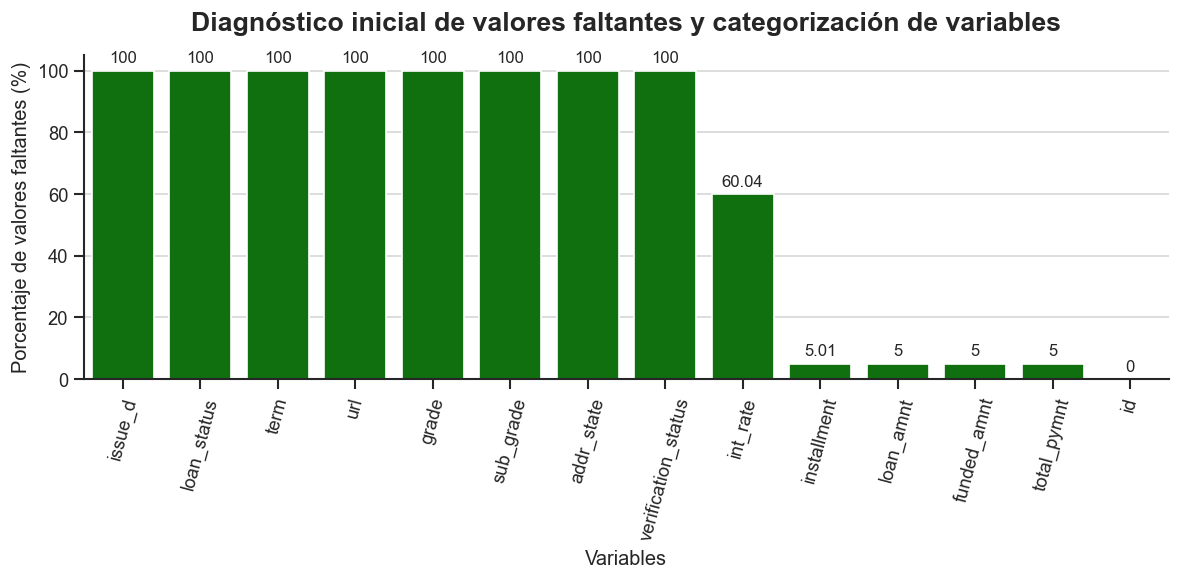

In [288]:
generacion_grafico_barra(
    datos=ordenado_pandas,
    columnas=ordenado_pandas.columns,
    titulo='Diagnóstico inicial de valores faltantes y categorización de variables',
    xlabel='Variables',
    ylabel='Porcentaje de valores faltantes (%)',
    ancho=10
)

---
---

A partir de los resultados obtenidos, se pueden establecer las siguientes conclusiones:

- Las variables `issue_d`, `loan_status`, `term`, `url`, `grade`, `sub_grade`, `addr_state` y `verification_status` no pueden convertirse directamente a un tipo de dato numérico, por lo que se clasifican preliminarmente como variables categóricas. Debido a la naturaleza de estas variables, el procedimiento empleado no permite evaluar, en esta etapa, la calidad o integridad de los datos asociados a sus registros.

- Aunque la variable `id` está compuesta por valores numéricos, su función es identificar de manera única cada registro del conjunto de datos. En consecuencia, se considera una variable categórica de identificación y no una variable numérica de análisis. Por esta razón, el porcentaje de valores no convertibles no constituye un criterio adecuado para evaluar la calidad de la información contenida en esta variable.

- Las variables `int_rate`, `loan_amnt`, `funded_amnt`, `installment` y `total_pymnt` presentan valores numéricos junto con diferentes proporciones de valores faltantes. Dado que la mayoría de sus registros corresponden a datos numéricos y que los valores no convertibles se asocian principalmente a registros ausentes, estas variables se clasifican como variables numéricas. No obstante, la presencia de valores faltantes evidencia diferencias en el nivel de integridad de la información disponible para cada una de ellas.

    En particular, se obtienen las siguientes métricas:

    * La variable `int_rate` presenta un **60.04 %** de valores faltantes, siendo la variable numérica con el mayor grado de pérdida de información.
    * La variable `installment` presenta un **5.01 %** de valores faltantes.
    * Las variables numéricas restantes presentan aproximadamente un **5 %** de valores faltantes, lo que indica un nivel de integridad significativamente superior al observado en `int_rate`.

---
---

In [289]:
lista_excepciones = ['id']

### 🤖 **Clasificación de las Agrupaciones de Datos**

---
---

Se realiza un análisis de las variables que componen el conjunto de datos con el propósito de identificar aquellas cuyos registros pueden convertirse a un tipo de dato numérico. Para ello, se evalúa el porcentaje de valores faltantes y de valores no convertibles obtenido en la etapa anterior, considerando además aquellas variables que, por su naturaleza, constituyen excepciones al criterio de clasificación.

A partir de este procedimiento se establecen los siguientes criterios:

* Si el porcentaje de valores no convertibles es igual al **100 %**, se concluye que ninguno de los registros de la variable puede interpretarse como un valor numérico. En consecuencia, la variable se clasifica preliminarmente como de naturaleza categórica.
* Las variables identificadas como excepciones no se clasifican utilizando el criterio anterior. Aunque sus registros estén representados mediante valores numéricos, su función dentro del conjunto de datos corresponde a categorías, etiquetas o identificadores, por lo que se consideran variables categóricas.

Es importante destacar que la capacidad de una variable para representarse mediante valores numéricos no implica necesariamente que esta sea una variable cuantitativa. En numerosos conjuntos de datos, las categorías, etiquetas o identificadores se codifican mediante números que carecen de significado numérico desde el punto de vista analítico.

Por esta razón, la clasificación definitiva de una variable no debe basarse únicamente en el formato de los datos que contiene, sino también en el propósito que desempeña dentro del conjunto de datos y en la naturaleza de la información que representa.

---
---

In [290]:
indice_numericos, indice_categoricos = clasificacion_variables(porcentajes=list(categoria_pandas['Porcentaje']), etiquetas=etiquetas, excepciones=lista_excepciones)

Lista de índices correspondientes a variables numéricas: [2, 4, 6, 7, 13]
Lista de índices correspondientes a variables categóricas: [0, 1, 3, 5, 8, 9, 10, 11, 12]


#### **Verificación del Proceso de Recategorización**

In [291]:
columnas_no_numericas, columnas_numericas = [], []

In [292]:
columnas_no_numericas = extraccion_columnas(
    categoria='Variables no numéricas',
    etiquetas=etiquetas,
    indices=indice_categoricos
)

Variables no numéricas
id
issue_d
loan_status
term
grade
sub_grade
verification_status
url
addr_state


In [293]:
columnas_numericas = extraccion_columnas(
    categoria='Variables numéricas',
    etiquetas=etiquetas,
    indices=indice_numericos
)

Variables numéricas
loan_amnt
funded_amnt
int_rate
installment
total_pymnt


### 🧠 **Cambio de Nombre de las Etiquetas**

___
___

Este procedimiento se realiza para proveerle una identificación más intuitiva a cada una de las variables contenidas en la base de datos
___
___

In [294]:
dic_etiquetas = {
    'id' : 'identificador',
    'issue_d' : 'fecha_prestamo',
    'loan_status' : 'estado_prestamo',
    'loan_amnt' : 'solicitud_prestamo_EUR',
    'funded_amnt' : 'aceptacion_prestamo_EUR',
    'term' : 'meses_prestamo',
    'grade' : 'grado',
    'sub_grade' : 'sub_grado',
    'verification_status' : 'estado_verificacion',
    'int_rate' : 'razon_intereses',
    'installment' : 'pago_mensual_EUR',
    'total_pymnt' : 'pago_efectuado_EUR',
    'url' : 'enlace',
    'addr_state' : 'estado',
}

In [295]:
etiquetas_previas = etiquetas.copy()
etiquetas = []

In [296]:
for i in etiquetas_previas:
    try:
        etiquetas.append(dic_etiquetas[i])
    except:
        pass

#### **Verificación del Proceso de Renombramiento de Variables**

In [297]:
columnas_no_numericas, columnas_numericas = [], []

In [298]:
columnas_no_numericas = extraccion_columnas(
    categoria='Variables no numéricas',
    etiquetas=etiquetas,
    indices=indice_categoricos
)

Variables no numéricas
identificador
fecha_prestamo
estado_prestamo
meses_prestamo
grado
sub_grado
estado_verificacion
enlace
estado


In [299]:
columnas_numericas = extraccion_columnas(
    categoria='Variables numéricas',
    etiquetas=etiquetas,
    indices=indice_numericos
)

Variables numéricas
solicitud_prestamo_EUR
aceptacion_prestamo_EUR
razon_intereses
pago_mensual_EUR
pago_efectuado_EUR


### 🤖 **Creación del DataFrame con Datos Crudos**

In [300]:
datos_pandas = pd.DataFrame(datos.transpose(), columns=etiquetas)
datos_pandas.info()


<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   identificador            10000 non-null  str  
 1   fecha_prestamo           10000 non-null  str  
 2   solicitud_prestamo_EUR   10000 non-null  str  
 3   estado_prestamo          10000 non-null  str  
 4   aceptacion_prestamo_EUR  10000 non-null  str  
 5   meses_prestamo           10000 non-null  str  
 6   razon_intereses          10000 non-null  str  
 7   pago_mensual_EUR         10000 non-null  str  
 8   grado                    10000 non-null  str  
 9   sub_grado                10000 non-null  str  
 10  estado_verificacion      10000 non-null  str  
 11  enlace                   10000 non-null  str  
 12  estado                   10000 non-null  str  
 13  pago_efectuado_EUR       10000 non-null  str  
dtypes: str(14)
memory usage: 1.1 MB


### 🤖 **Casteo de los Datos en el DataFrame**

#### *Variables Numéricas*

In [301]:
datos_pandas[columnas_numericas] = datos_pandas[columnas_numericas].apply(pd.to_numeric, errors = 'coerce')

In [302]:
datos_pandas.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   identificador            10000 non-null  str    
 1   fecha_prestamo           10000 non-null  str    
 2   solicitud_prestamo_EUR   9500 non-null   float64
 3   estado_prestamo          10000 non-null  str    
 4   aceptacion_prestamo_EUR  9500 non-null   float64
 5   meses_prestamo           10000 non-null  str    
 6   razon_intereses          3996 non-null   float64
 7   pago_mensual_EUR         9499 non-null   float64
 8   grado                    10000 non-null  str    
 9   sub_grado                10000 non-null  str    
 10  estado_verificacion      10000 non-null  str    
 11  enlace                   10000 non-null  str    
 12  estado                   10000 non-null  str    
 13  pago_efectuado_EUR       9500 non-null   float64
dtypes: float64(5), str(9)
memory usage

#### *Variables No Numéricas*

In [303]:
datos_pandas[columnas_no_numericas] = datos_pandas[columnas_no_numericas].replace('', np.nan)

In [304]:
datos_pandas.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   identificador            10000 non-null  str    
 1   fecha_prestamo           9500 non-null   str    
 2   solicitud_prestamo_EUR   9500 non-null   float64
 3   estado_prestamo          9500 non-null   str    
 4   aceptacion_prestamo_EUR  9500 non-null   float64
 5   meses_prestamo           9500 non-null   str    
 6   razon_intereses          3996 non-null   float64
 7   pago_mensual_EUR         9499 non-null   float64
 8   grado                    9485 non-null   str    
 9   sub_grado                9486 non-null   str    
 10  estado_verificacion      9500 non-null   str    
 11  enlace                   10000 non-null  str    
 12  estado                   9500 non-null   str    
 13  pago_efectuado_EUR       9500 non-null   float64
dtypes: float64(5), str(9)
memory usage

### 🧠 **Exploración Métrica de la Base de Datos**

####  **Métricas de Completitud / Ausencia de Datos**

___
___

Una vez obtenida la estructura de datos resultante de las etapas anteriores, se dispone de un conjunto de datos consistente en cuanto al formato de las variables y a la identificación de los valores presentes y ausentes. A partir de esta estructura es posible calcular diferentes indicadores que permiten evaluar la completitud del conjunto de datos desde distintas perspectivas.

Las métricas consideradas en esta etapa son las siguientes:

* Cantidad total de valores ausentes presentes en el conjunto de datos.

* Cantidad de variables que contienen al menos un valor ausente.

* Cantidad de registros que contienen al menos un valor ausente.

* Distribución de los valores ausentes por variable.

* Distribución de los valores ausentes por registro.

El análisis conjunto de estos indicadores permite evaluar el grado de completitud de la información disponible, identificando tanto las variables como los registros más afectados por la asuencia de datos. Esta caracterización constituye un insumo fundamental para definir las estrategias de limpieza e imputación que se aplicarán en las etapas posteriores del proceso de preprocesamiento de datos.
___
___

#####  *Métricas Generalizadas de la Base de Datos*

In [305]:
cantidad_nulos = datos_pandas.isna().sum(axis=0).sum()
cantidad_total = datos_pandas.count().sum() + cantidad_nulos
print(f'Total de datos faltantes: {cantidad_nulos}')
print(f'Total de valores en la base de datos: {cantidad_total}')
print(f'Proporción de valores faltantes con relación al total: {round(cantidad_nulos/cantidad_total*100, 3)} %')
print(f'Índice global de completitud {round((1-cantidad_nulos/cantidad_total)*100, 3)} %')

Total de datos faltantes: 11534
Total de valores en la base de datos: 140000
Proporción de valores faltantes con relación al total: 8.239 %
Índice global de completitud 91.761 %


In [306]:
registros_valores_nulos = (datos_pandas.isna().sum(axis=1) > 0).sum()
total_registros_nulos = datos_pandas.shape[0]

print(f'Total de registros con valores faltantes: {registros_valores_nulos}')
print(f'Total de registros: {total_registros_nulos}')
print(f'Proporción de registros faltantes con relación al total: {round(registros_valores_nulos/total_registros_nulos*100, 3)} %')
print(f'Índice de completitud de los registros {round((1-registros_valores_nulos/total_registros_nulos)*100, 3)} %')

Total de registros con valores faltantes: 8317
Total de registros: 10000
Proporción de registros faltantes con relación al total: 83.17 %
Índice de completitud de los registros 16.83 %


In [307]:
variables_valores_nulos = (datos_pandas.isna().sum(axis=0) > 0).sum()
total_variables_nulos = datos_pandas.shape[1]

print(f'Total de variables con valores faltantes: {variables_valores_nulos}')
print(f'Total de variables: {total_variables_nulos}')
print(f'Proporción de variables faltantes con relación al total: {round(variables_valores_nulos/total_variables_nulos*100,3)} %')
print(f'Índice de completitud de las variables {round((1-variables_valores_nulos/total_variables_nulos)*100, 3)} %')

Total de variables con valores faltantes: 12
Total de variables: 14
Proporción de variables faltantes con relación al total: 85.714 %
Índice de completitud de las variables 14.286 %


#####  ⭐ *Observaciones*

___
___

A partir de las métricas analíticas de completitud obtenidas del conjunto de datos, se obtienen los siguientes indicadores globales:

* La base de datos contiene un total de 140 000 datos, distribuidos por 1 000 registros y 14 variables. 

* El conjunto de datos contiene un total de 11 534 valores ausentes, lo que representa el 8.24 % del total de 140 000 valores que conforman la base de datos. En consecuencia, el índice global de completitud es del 91.76 %, lo que indica que la mayor parte de la información requerida se encuentra disponible.

* De los 10 000 registros analizados, 8 317 presentan al menos un valor ausente. Esto equivale al 83.17 % del total de registros, mientras que únicamente el 16.83 % de los registros se encuentran completamente definidos, es decir, no contienen valores faltantes.

* En cuanto a las variables, 12 de las 14 presentan al menos un valor ausente, lo que representa el 85.71 % del total de variables. En consecuencia, únicamente 2 variables (14.29 %) poseen información completamente íntegra en todos sus registros.

Estos indicadores muestran que:

* Si bien la proporción global de valores ausentes es relativamente reducida, representando únicamente el 8.24 % del total de datos contenidos en la base de datos, la distribución de dichos valores faltantes se encuentra ampliamente dispersa tanto entre los registros como entre las variables. En particular, el 83.17 % de los registros presenta al menos un valor ausente y el 85.71 % de las variables contiene información incompleta. Estos resultados evidencian que, aunque la cantidad total de valores faltantes no es elevada, su distribución afecta a una gran parte de la estructura del conjunto de datos, lo que justifica la aplicación de técnicas de limpieza e imputación antes de llevar a cabo análisis posteriores.

___
___

#####  *Completitud por variable*

In [308]:
completitud_variables_pandas, completitud_variables_ordenado = completitud_variables_datos(datos=datos_pandas, etiquetas=etiquetas)

                  Categoria  Porcentaje
0             identificador        0.00
1            fecha_prestamo        5.00
2    solicitud_prestamo_EUR        5.00
3           estado_prestamo        5.00
4   aceptacion_prestamo_EUR        5.00
5            meses_prestamo        5.00
6           razon_intereses       60.04
7          pago_mensual_EUR        5.01
8                     grado        5.15
9                 sub_grado        5.14
10      estado_verificacion        5.00
11                   enlace        0.00
12                   estado        5.00
13       pago_efectuado_EUR        5.00


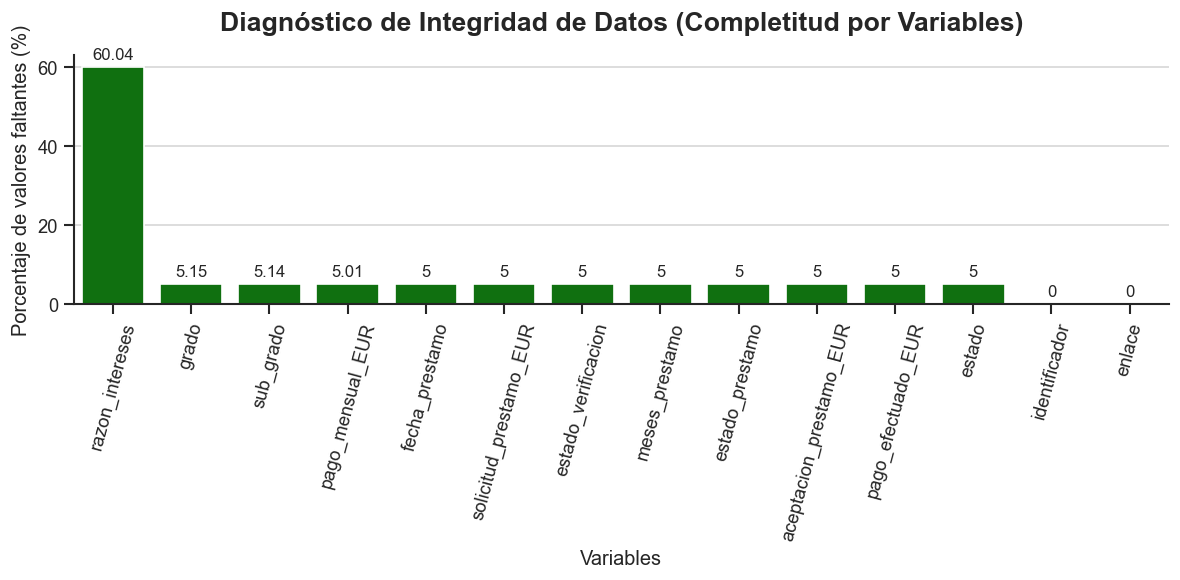

In [309]:
generacion_grafico_barra(
    datos=completitud_variables_ordenado,
    columnas=completitud_variables_ordenado.columns,
    titulo='Diagnóstico de Integridad de Datos (Completitud por Variables)',
    xlabel='Variables',
    ylabel='Porcentaje de valores faltantes (%)',
    ancho=10
)

##### ⭐ *Observaciones*

___
___

A partir de los resultados obtenidos en la gráfica correspondiente a la caracterización de valores ausentes por cada una de las variables de la base de datos, se establecen las siguientes conclusiones:

- La variable `razon_interes` presenta el mayor porcentaje de valores faltantes del conjunto de datos. En consecuencia, si no es posible aplicar una estrategia de imputación adecuada, la información disponible para esta variable resulta limitada para realizar análisis posteriores, ya que el **60.04 %** de sus registros se encuentra ausente.

- Las variables `identificador` y `enlace` presentan un **100 %** de completitud, por lo que no requieren la aplicación de procedimientos de imputación relacionados con la presencia de valores faltantes.

- Las demás variables presentan bajos porcentajes de valores faltantes **(~5 %)**. No obstante, su nivel de integridad puede mejorarse mediante la aplicación de técnicas de imputación, siempre que estas se encuentren debidamente justificadas y fundamentadas en la relación existente entre las variables del conjunto de datos.

---
___

#####  *Completitud por registro*

In [310]:
completitud_registros_pandas = completitud_registros_datos(datos=datos_pandas)

   Cantidad_nulos  Porcentaje
2               0       16.83
0               1       51.11
1               2       31.96
3               3        0.09
4               4        0.01


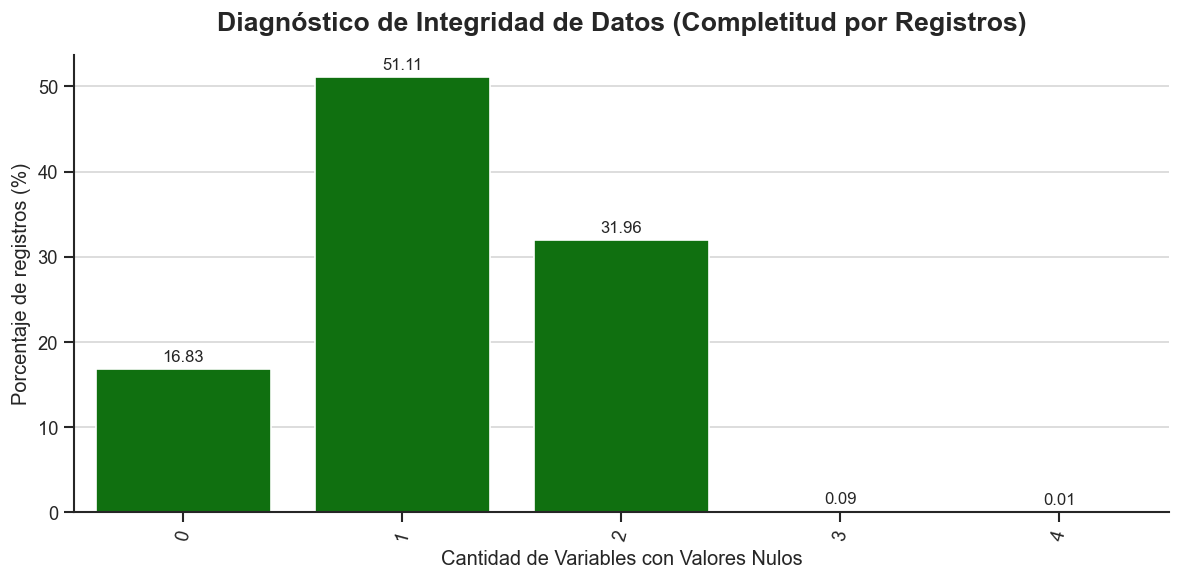

In [311]:
generacion_grafico_barra(
    datos=completitud_registros_pandas,
    columnas=completitud_registros_pandas.columns,
    titulo='Diagnóstico de Integridad de Datos (Completitud por Registros)',
    xlabel='Cantidad de Variables con Valores Nulos',
    ylabel='Porcentaje de registros (%)',
    ancho=10
)

##### ⭐ *Observaciones*


___
___

En los resultados obtenidos se observa que el **51.11 %** de los registros de la base de datos presenta únicamente una variable con un valor faltante. Este resultado pone de manifiesto la importancia de implementar un proceso de imputación, ya que, de no realizarse, una proporción considerable de los registros podría descartarse durante las etapas posteriores de análisis, reduciendo el tamaño efectivo de la muestra y la representatividad de los resultados.

Asimismo, el **31.96 %** de los registros contiene dos variables con valores faltantes. Esta situación evidencia la existencia de un grado apreciable de concurrencia de datos ausentes dentro de un mismo registro, fenómeno que probablemente se encuentra influenciado por la elevada proporción de valores faltantes observada en la variable correspondiente a la tasa de interés. En consecuencia, la ausencia de información en dicha variable incrementa la probabilidad de que un registro acumule más de un dato faltante.

Por otra parte, los registros que presentan tres o más valores faltantes representan únicamente el **0.10 %** del conjunto de datos, por lo que su incidencia resulta prácticamente despreciable. Este comportamiento es consistente con el hecho de que únicamente una variable exhibe una proporción elevada de valores ausentes, mientras que el resto presenta porcentajes de datos faltantes considerablemente menores. En consecuencia, no se observa evidencia de un patrón de ausencia que afecte simultáneamente a un gran número de variables dentro de un mismo registro, aunque serían necesarios análisis adicionales para determinar formalmente el mecanismo de ausencia de los datos (MCAR, MAR o MNAR).

Finalmente, solo el **16.83 %** de los registros conserva la totalidad de sus variables sin valores faltantes, lo que indica que más del **83 %** de la información disponible requiere algún tipo de tratamiento previo antes de ser utilizada en procesos analíticos. Este resultado justifica la implementación de un procedimiento sistemático de limpieza e imputación de datos, siempre que las técnicas empleadas se encuentren debidamente fundamentadas y sean consistentes con la naturaleza de las variables y con el mecanismo de generación de los valores ausentes.
___
___

####  **Métricas de Unicidad / Duplicidad de Datos**

___
___

A continuación, se realiza un análisis de la duplicidad presente en el conjunto de datos, con el objetivo de identificar tanto la existencia de registros redundantes como la presencia de valores duplicados en las variables de identificación de registros que han sido proveídas. Este análisis permite evaluar la unicidad de la información y detectar posibles inconsistencias derivadas de la repetición de datos.

Las métricas consideradas en esta etapa son las siguientes:

* Cantidad total de registros duplicados en el conjunto de datos.

* Cantidad de valores duplicados por cada una de las variables de identificación.

El análisis conjunto de estos indicadores permite identificar la existencia de información redundante y determinar si la presencia de registros o valores repetidos puede afectar la representatividad del conjunto de datos. Los resultados obtenidos constituyen un criterio fundamental para decidir la aplicación de procedimientos de eliminación de duplicados o de consolidación de registros antes de continuar con las etapas posteriores de limpieza y preprocesamiento.

___
___

##### *Registros duplicados*

In [312]:
registros_duplicados = datos_pandas.duplicated().sum()
total_registros = datos_pandas.shape[0]
print(f'Cantidad de registros duplicados: {registros_duplicados}')
print(f'Total de registros: {total_registros}')
print(f'Proporción de registros duplicados: {round(registros_duplicados/total_registros*100, 2)} %')
print(f'Índice de unicidad de los registros: {round((1 - registros_duplicados/total_registros)*100, 2)} %')

Cantidad de registros duplicados: 0
Total de registros: 10000
Proporción de registros duplicados: 0.0 %
Índice de unicidad de los registros: 100.0 %


#####  *Identificadores duplicados*

In [313]:
identificadores_duplicados = datos_pandas[etiquetas[0]].duplicated().sum()
total_registros = datos_pandas['identificador'].shape[0]
print(f'Cantidad de identificadores duplicados: {identificadores_duplicados}')
print(f'Total de registros: {total_registros}')
print(f'Proporción de identificadores duplicados: {round(identificadores_duplicados/total_registros*100, 2)} %')
print(f'Índice de unicidad de los identificadores: {round((1 - identificadores_duplicados/total_registros)*100, 2)} %')

Cantidad de identificadores duplicados: 0
Total de registros: 10000
Proporción de identificadores duplicados: 0.0 %
Índice de unicidad de los identificadores: 100.0 %


##### ⭐ *Observaciones*

___
___

A partir de los indicadores obtenidos se establecen las siguientes conclusiones:

- No se identificaron registros duplicados en la base de datos. Este resultado indica que cada observación representa un préstamo diferente y que no existen registros redundantes que puedan introducir sesgos en los análisis estadísticos.

- La totalidad de los 10 000 registros corresponden a observaciones únicas, por lo que el índice de unicidad de los registros es del **100 %**. En consecuencia, no es necesario aplicar procedimientos de eliminación de registros duplicados durante la etapa de limpieza de datos.

- Asimismo, no se detectaron identificadores duplicados, lo que confirma que la variable identificador cumple adecuadamente su función como clave única del conjunto de datos. Esta propiedad garantiza que cada préstamo puede ser identificado de manera unívoca.

- La ausencia simultánea de registros duplicados y de identificadores repetidos constituye un indicador favorable de la integridad estructural del conjunto de datos, ya que evidencia que no existen problemas asociados a la replicación accidental de información.

Aunque no fue necesario realizar acciones correctivas en esta etapa, la verificación de la unicidad de los registros y de los identificadores representa una buena práctica dentro del proceso de limpieza de datos, puesto que permite descartar de forma temprana posibles inconsistencias que podrían afectar la calidad de los análisis posteriores.

___
___

##### 🛠️ *Cambios efectuados*

Eliminación de registros duplicados

In [314]:
datos_pandas = datos_pandas.drop_duplicates()

Sería importante analizar los casos en los cuales la variable de identificación posea un duplicado posterior al proceso de eliminación realizado

In [315]:
datos_pandas[datos_pandas['identificador'].duplicated()]

,identificador,fecha_prestamo,solicitud_prestamo_EUR,estado_prestamo,aceptacion_prestamo_EUR,meses_prestamo,razon_intereses,pago_mensual_EUR,grado,sub_grado,estado_verificacion,enlace,estado,pago_efectuado_EUR


####  **Métricas de Cardinalidad de Datos**

___
___

Una vez evaluadas la completitud y la unicidad del conjunto de datos, resulta conveniente analizar la cardinalidad de las variables que lo componen. La cardinalidad se refiere al número de valores distintos que puede tomar una variable dentro del conjunto de datos y constituye una característica fundamental para comprender la naturaleza de la información almacenada.

El estudio de la cardinalidad permite:

* Diferenciar variables identificadoras, variables numéricas continuas y variables categóricas.

* Detectar posibles anomalías relacionadas con la presencia de valores inesperados, categorías mal definidas o una variabilidad inferior o superior a la esperada. 

* Proporciona información útil para la selección de estrategias de codificación, agrupación de categorías y reducción de variables durante las etapas posteriores del preprocesamiento de datos.

Las métricas consideradas en esta etapa son las siguientes:

- Cardinalidad absoluta por variable.

- Cardinalidad relativa por variable.

- Clasificación de la cardinalidad de las variables.

- Comparación entre la clasificación de la cardinalidad de los datos y el formato aplicado a cada una de las variables

El análisis conjunto de estos indicadores permite caracterizar el grado de diversidad de la información contenida en cada variable y evaluar si dicha diversidad es consistente con la naturaleza de los datos que representa.

___
___

##### *Cardinalidad Absoluta*

___
___

La cardinalidad absoluta se corresponde a la cantidad de valores únicos presentes en cada una de las variables que componen la base de datos proveída.
___
___

In [316]:
unicos_pandas = pd.DataFrame({
    'Categoría': etiquetas,
    'Cantidad de Valores Unicos': datos_pandas[etiquetas].fillna('N/A').nunique().values
})

unicos_pandas_ordenados = unicos_pandas.sort_values('Cantidad de Valores Unicos', ascending=False)

unicos_pandas.head()

,Categoría,Cantidad de Valores Unicos
0,identificador,10000
1,fecha_prestamo,13
2,solicitud_prestamo_EUR,886
3,estado_prestamo,9
4,aceptacion_prestamo_EUR,890


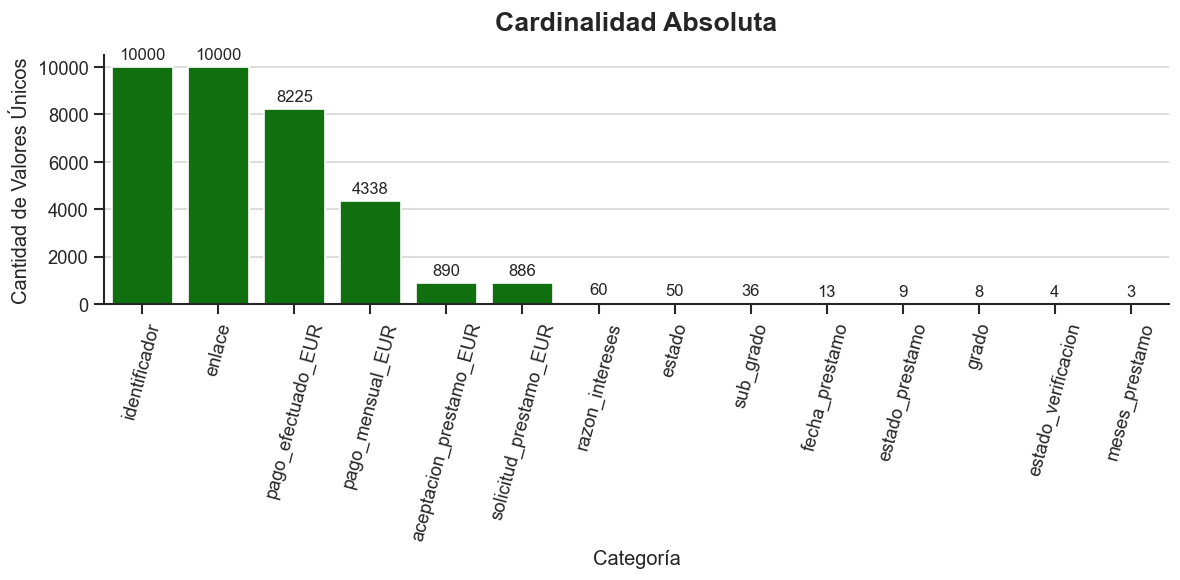

In [317]:
generacion_grafico_barra(
    datos=unicos_pandas_ordenados,
    columnas=unicos_pandas.columns,
    xlabel='Categoría',
    ylabel='Cantidad de Valores Únicos',
    titulo='Cardinalidad Absoluta',
    ancho=10
)

##### ⭐ *Observaciones*

___
___

A partir del análisis de la cardinalidad absoluta de las variables que conforman la base de datos, se obtienen las siguientes conclusiones:

* Las variables `identificador` y `enlace` presentan **10 000** valores únicos, equivalentes al número total de registros del conjunto de datos. Esta característica confirma que ambas variables pueden emplearse como identificadores únicos de cada observación. Sin embargo, debido a que ambas cumplen una función similar, es conveniente evaluar la posible redundancia de la información que contienen.

* Las variables `pago_efectuado_EUR` y `pago_mensual_EUR` presentan una cardinalidad elevada, con **8 225** y **4 338** valores únicos, respectivamente. Este comportamiento es consistente con la naturaleza continua de las variables monetarias, en las cuales es esperable una amplia diversidad de valores debido a las diferencias existentes entre los préstamos otorgados y los pagos realizados.

* Las variables `aceptacion_prestamo_EUR` y `solicitud_prestamo_EUR` presentan una cardinalidad intermedia (**890** y **886** valores únicos, respectivamente), lo que indica que, aunque existe una diversidad considerable de montos, diferentes registros comparten los mismos valores. Este comportamiento es habitual en variables financieras cuyos importes suelen concentrarse alrededor de determinados montos de referencia.

* La variable `razon_intereses` presenta únicamente **60** valores únicos, comportamiento consistente con una tasa de interés que únicamente puede tomar un conjunto limitado de valores. No obstante, este resultado debe analizarse conjuntamente con el estudio de completitud, ya que la elevada proporción de valores ausentes identificada previamente puede haber reducido la diversidad observada.

* La variable `estado` contiene **50** valores únicos, resultado que coincide con el número de estados que conforman los Estados Unidos. Esto sugiere que la cobertura geográfica del conjunto de datos es consistente con el dominio esperado para dicha variable.

* Las variables `sub_grado`, `grado`, `estado_prestamo`, `estado_verificacion`, `fecha_prestamo` y `meses_prestamo` presentan una baja cardinalidad. Este comportamiento es coherente con su naturaleza categórica, ya que representan atributos cuyos valores pertenecen a un conjunto reducido y previamente definido de categorías.

En términos generales, la distribución de la cardinalidad es consistente con la función que desempeña cada variable dentro del conjunto de datos. No se identifican anomalías que indiquen una diversidad excesiva o insuficiente de valores respecto a la naturaleza esperada de la información almacenada.
___
___

##### *Cardinalidad Relativa*

___
___

La cardinalidad relativa se define como la proporción de valores únicos que presenta una variable con relación al número total de registros del conjunto de datos. Esta métrica constituye una medida normalizada de la diversidad de los valores contenidos en cada variable, lo que permite comparar su comportamiento entre diferentes bases de datos sin que el tamaño de la muestra influya en la interpretación de los resultados. En consecuencia, la cardinalidad relativa representa un criterio útil para la clasificación de variables y el análisis de la estructura del conjunto de datos.

___
___

In [318]:
unicos_pandas_proporcion = unicos_pandas.copy()
unicos_pandas_proporcion['Proporcion'] = unicos_pandas_proporcion['Cantidad de Valores Unicos']/datos_pandas.shape[0]*100
unicos_pandas_proporcion = unicos_pandas_proporcion.drop('Cantidad de Valores Unicos', axis=1)
unicos_pandas_proporcion_ordenados = unicos_pandas_proporcion.sort_values('Proporcion', ascending=False)
unicos_pandas_proporcion.head()

,Categoría,Proporcion
0,identificador,100.00
1,fecha_prestamo,0.13
2,solicitud_prestamo_EUR,8.86
3,estado_prestamo,0.09
4,aceptacion_prestamo_EUR,8.90


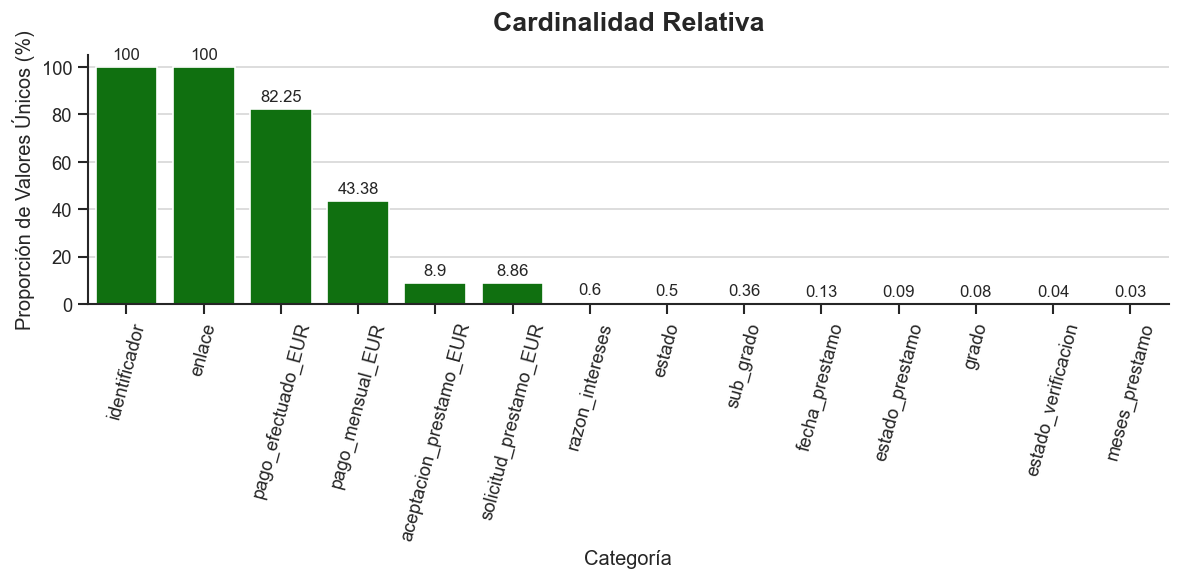

In [319]:
generacion_grafico_barra(
    datos=unicos_pandas_proporcion_ordenados,
    columnas=unicos_pandas_proporcion_ordenados.columns,
    xlabel='Categoría',
    ylabel='Proporción de Valores Únicos (%)',
    titulo='Cardinalidad Relativa',
    ancho=10
)

##### ⭐ *Observaciones*

___
___

Los resultados obtenidos son consistentes con los presentados en el análisis de cardinalidad absoluta, ya que la cardinalidad relativa constituye una versión normalizada de dicho indicador. 

En particular, se verifica que las variables `identificador` y `enlace` presentan una cardinalidad relativa del 100 %, lo que confirma que cada registro posee un valor único para ambas variables. Este comportamiento es característico de variables utilizadas como identificadores y sugiere la posible existencia de redundancia de información entre ellas, aspecto que deberá analizarse en etapas posteriores.

Adicionalmente, la cardinalidad relativa proporciona un criterio objetivo para clasificar las variables según su grado de diversidad, independientemente del tamaño del conjunto de datos. Resulta conveniente comparar esta clasificación con la obtenida durante la etapa inicial del análisis exploratorio, en la cual las variables fueron clasificadas de acuerdo con el formato de los datos que contienen (numéricas o no numéricas).

La comparación entre ambos criterios de clasificación permite detectar posibles inconsistencias o anomalías. Por ejemplo, una variable identificada inicialmente como categórica podría presentar una cardinalidad muy elevada, indicando que en realidad se comporta como un identificador o una variable continua. De forma análoga, una variable clasificada como numérica podría exhibir una cardinalidad reducida, lo que sugeriría que representa un conjunto limitado de categorías codificadas mediante valores numéricos. En consecuencia, el análisis conjunto del tipo de dato y de la cardinalidad proporciona una caracterización más completa de la naturaleza de las variables que integran el conjunto de datos.
___
___

##### *Clasificación de la Cardinalidad*

___
___

Con el propósito de facilitar la interpretación de los resultados obtenidos, las variables se clasifican de acuerdo con su cardinalidad relativa, empleando un conjunto de intervalos definidos específicamente para el presente estudio. Esta clasificación constituye un criterio metodológico orientado a caracterizar el grado de diversidad de los valores contenidos en cada variable y a facilitar la comparación entre ellas, independientemente del tamaño del conjunto de datos.

La clasificación adoptada es la siguiente:

- **Cardinalidad muy alta**: mayor que **80 %**.
- **Cardinalidad alta**: entre **20 %** y **80 %**.
- **Cardinalidad media**: entre **5 %** y **20 %**.
- **Cardinalidad baja**: entre **1 %** y **5 %**.
- **Cardinalidad muy baja**: menor que **1 %**.

Esta clasificación se emplea únicamente con fines descriptivos y de interpretación, permitiendo identificar de manera sistemática variables con un elevado grado de diversidad, variables predominantemente categóricas y posibles variables que desempeñan funciones de identificación dentro del conjunto de datos.

___
___

In [320]:
unicos_pandas_clasificados = unicos_pandas_proporcion.copy()

# Clasificación por defecto
unicos_pandas_clasificados['Clasificacion'] = 'Muy baja'

dict_umbrales = {
    1: 'Baja',
    5: 'Media',
    20: 'Alta',
    80: 'Muy alta'
}

for umbral, clasificacion in dict_umbrales.items():
    unicos_pandas_clasificados.loc[
        unicos_pandas_clasificados['Proporcion'] > umbral,
        'Clasificacion'
    ] = clasificacion

unicos_pandas_clasificados = unicos_pandas_clasificados.drop('Proporcion', axis=1)

unicos_pandas_clasificados[:]

,Categoría,Clasificacion
0,identificador,Muy alta
1,fecha_prestamo,Muy baja
2,solicitud_prestamo_EUR,Media
3,estado_prestamo,Muy baja
4,aceptacion_prestamo_EUR,Media
5,meses_prestamo,Muy baja
6,razon_intereses,Muy baja
7,pago_mensual_EUR,Alta
8,grado,Muy baja
9,sub_grado,Muy baja


In [321]:
distribucion_clasificaciones_pandas = pd.DataFrame(unicos_pandas_clasificados.value_counts('Clasificacion').reset_index())
distribucion_clasificaciones_pandas

,Clasificacion,count
0,Muy baja,8
1,Muy alta,3
2,Media,2
3,Alta,1


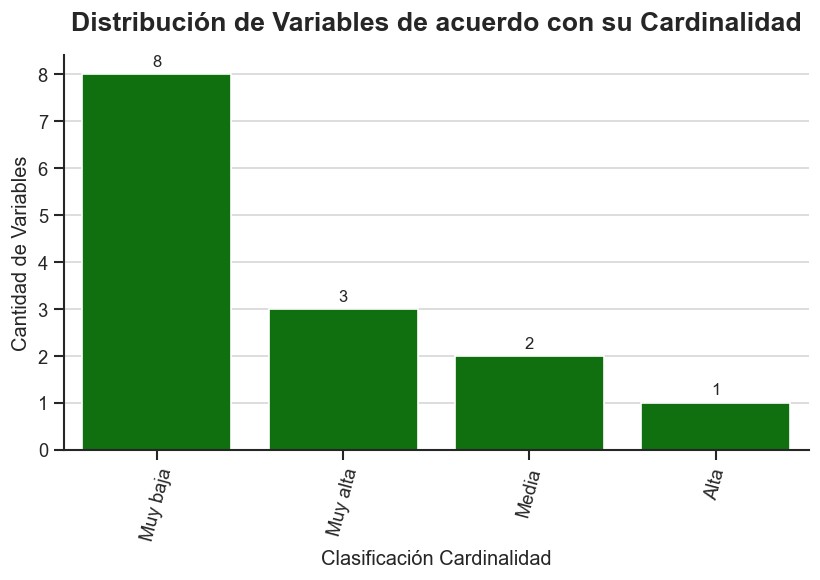

In [322]:
generacion_grafico_barra(
     datos=distribucion_clasificaciones_pandas,
     columnas=distribucion_clasificaciones_pandas.columns,
     titulo='Distribución de Variables de acuerdo con su Cardinalidad',
     xlabel='Clasificación Cardinalidad',
     ylabel='Cantidad de Variables'
)

##### ⭐ *Observaciones*

___
___

A partir de la clasificación de las variables según su cardinalidad relativa, se obtienen las siguientes conclusiones:

* La mayor parte de las variables de la base de datos (8 de las 14 variables analizadas) presentan una cardinalidad muy baja, lo que indica que están compuestas por un número reducido de valores distintos con relación al total de registros. Este comportamiento es característico de variables categóricas o de variables cuyos valores pertenecen a un dominio previamente definido.

* Se identifican tres variables con cardinalidad muy alta, las cuales presentan una elevada diversidad de valores. Este resultado es consistente con variables utilizadas como identificadores o con variables numéricas continuas, cuya naturaleza favorece la existencia de un gran número de valores distintos.

* Únicamente dos variables presentan una cardinalidad media, lo que evidencia una diversidad moderada de valores. Estas variables pueden corresponder a atributos numéricos discretos o a variables cuyos valores se encuentran concentrados en un conjunto limitado de posibilidades.

* Solo una variable fue clasificada con cardinalidad alta, indicando que, aunque existe una elevada diversidad de valores, esta no alcanza el nivel observado en las variables clasificadas como de cardinalidad muy alta.

En términos generales, la distribución de la cardinalidad refleja una estructura equilibrada y coherente con la naturaleza del conjunto de datos, en la que predominan las variables categóricas de baja diversidad y un grupo reducido de variables con elevada cardinalidad asociadas a identificadores y magnitudes numéricas.

La clasificación obtenida constituye un criterio complementario al análisis basado en el tipo de dato de las variables. Mientras que la clasificación inicial permite distinguir entre variables numéricas y no numéricas, el estudio de la cardinalidad proporciona información acerca del grado de diversidad de los valores que contiene cada variable. La combinación de ambos enfoques facilita la identificación de variables identificadoras, variables categóricas y variables numéricas, además de contribuir a la detección de posibles inconsistencias o anomalías en la estructura del conjunto de datos.
___
___

##### *Comparación Cardinalidad vs Formato*

In [323]:
unicos_pandas_comparacion = unicos_pandas_clasificados.copy()

unicos_pandas_comparacion.rename(
    columns={
        'Clasificacion' : 'Clasificacion Cardinalidad'
    }, inplace=True
)

unicos_pandas_comparacion['Clasificacion Formato'] = 'No Numérica'

unicos_pandas_comparacion.loc[unicos_pandas_comparacion['Categoría'].isin(columnas_numericas), 'Clasificacion Formato'] = 'Numérica'

unicos_pandas_comparacion[:]

,Categoría,Clasificacion Cardinalidad,Clasificacion Formato
0,identificador,Muy alta,No Numérica
1,fecha_prestamo,Muy baja,No Numérica
2,solicitud_prestamo_EUR,Media,Numérica
3,estado_prestamo,Muy baja,No Numérica
4,aceptacion_prestamo_EUR,Media,Numérica
5,meses_prestamo,Muy baja,No Numérica
6,razon_intereses,Muy baja,Numérica
7,pago_mensual_EUR,Alta,Numérica
8,grado,Muy baja,No Numérica
9,sub_grado,Muy baja,No Numérica


In [324]:
distribucion_categorica = (
    unicos_pandas_comparacion
    .groupby(
        ['Clasificacion Formato', 'Clasificacion Cardinalidad']
    )
    .size()
    .reset_index(name='Cantidad')
)

distribucion_categorica

,Clasificacion Formato,Clasificacion Cardinalidad,Cantidad
0,No Numérica,Muy alta,2
1,No Numérica,Muy baja,7
2,Numérica,Alta,1
3,Numérica,Media,2
4,Numérica,Muy alta,1
5,Numérica,Muy baja,1


In [325]:
distribucion_no_numerico = distribucion_categorica[distribucion_categorica['Clasificacion Formato']=='No Numérica'].drop('Clasificacion Formato', axis=1)
distribucion_no_numerico

,Clasificacion Cardinalidad,Cantidad
0,Muy alta,2
1,Muy baja,7


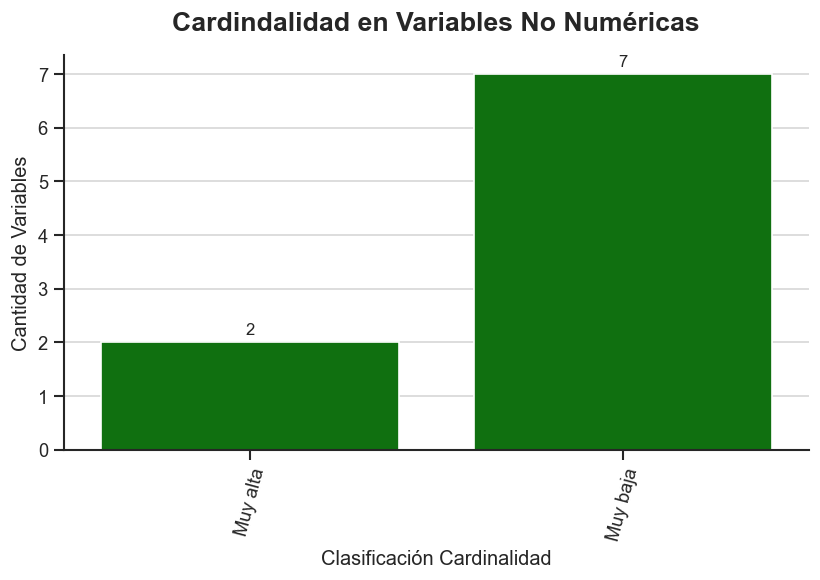

In [326]:
generacion_grafico_barra(
    datos=distribucion_no_numerico,
    columnas=distribucion_no_numerico.columns,
    titulo='Cardindalidad en Variables No Numéricas',
    xlabel='Clasificación Cardinalidad',
    ylabel='Cantidad de Variables'
)

In [327]:
distribucion_numerico = distribucion_categorica[distribucion_categorica['Clasificacion Formato']=='Numérica'].drop('Clasificacion Formato', axis=1)
distribucion_numerico

,Clasificacion Cardinalidad,Cantidad
2,Alta,1
3,Media,2
4,Muy alta,1
5,Muy baja,1


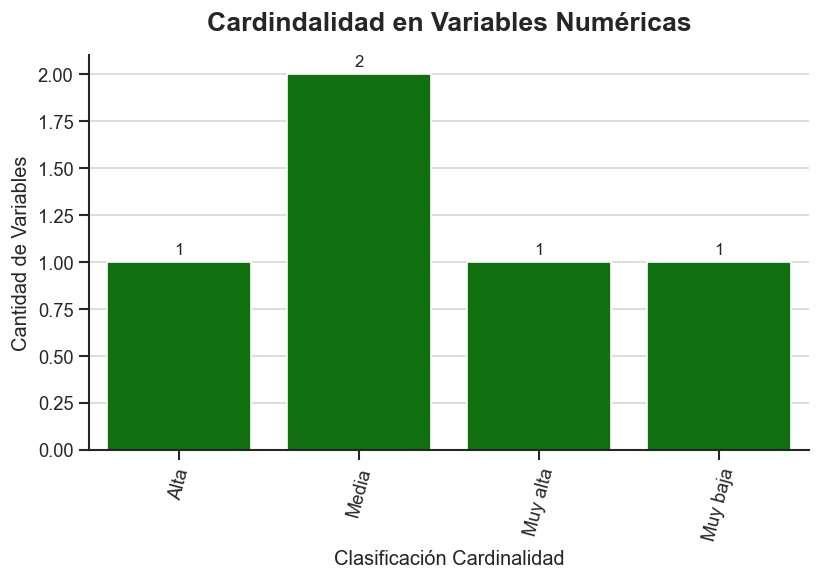

In [328]:
generacion_grafico_barra(
    datos=distribucion_numerico,
    columnas=distribucion_numerico.columns,
    titulo='Cardindalidad en Variables Numéricas',
    xlabel='Clasificación Cardinalidad',
    ylabel='Cantidad de Variables'
)

##### ⭐ *Observaciones*

___
___

A partir de la comparación entre la clasificación de las variables según su formato y su nivel de cardinalidad, se obtienen las siguientes conclusiones:

* La mayoría de las variables no numéricas (7 de 9) presentan una cardinalidad muy baja, lo cual es consistente con su naturaleza categórica. Este comportamiento indica que dichas variables están compuestas por un conjunto reducido de categorías, característica esperada en atributos como estados, grados o clasificaciones.

* Dentro del conjunto de variables no numéricas, únicamente dos variables presentan una cardinalidad muy alta. Este resultado corresponde a las variables `identificador` y `enlace`, las cuales fueron clasificadas inicialmente como no numéricas debido a su formato, pero cuya elevada cardinalidad confirma que desempeñan la función de identificadores únicos de los registros y no la de variables categóricas convencionales.

* Las variables numéricas presentan una distribución de cardinalidad más heterogénea. Se identifican variables con cardinalidad media, alta y muy alta, comportamiento esperado en variables cuantitativas asociadas a montos, pagos y tasas de interés, cuyos valores presentan diferentes niveles de variabilidad.

* Se identifica una variable numérica con cardinalidad muy baja, correspondiente a `razon_intereses`. En principio, este comportamiento podría sugerir que la variable está compuesta por un conjunto reducido de valores posibles, característica propia de variables categóricas codificadas mediante valores numéricos. Sin embargo, esta conclusión no puede establecerse únicamente a partir del análisis de la cardinalidad.

    Es importante considerar que razon_intereses presenta la mayor proporción de valores ausentes dentro del conjunto de datos, lo que puede reducir significativamente el número de valores únicos observados y afectar la estimación de su cardinalidad. Adicionalmente, al tratarse de una tasa de interés, es posible que los valores se encuentren discretizados o redondeados, circunstancia que también disminuiría el número de valores distintos sin modificar la naturaleza cuantitativa de la variable.

    En consecuencia, los resultados obtenidos constituyen un indicio de que esta variable requiere un análisis más detallado. En las etapas posteriores del proceso de preprocesamiento será necesario estudiar su distribución, la frecuencia de sus valores y el mecanismo asociado a la ausencia de datos, con el propósito de determinar si la baja cardinalidad responde a las características propias de la variable o si constituye una anomalía derivada de la calidad de los datos.

En conjunto, la comparación entre ambas clasificaciones confirma que el criterio basado en el formato de los datos y el criterio basado en la cardinalidad son complementarios. Mientras que el primero identifica la representación de los datos, el segundo caracteriza la diversidad de los valores contenidos en cada variable. La utilización conjunta de ambos enfoques permite describir con mayor precisión la naturaleza de las variables y detectar posibles excepciones que requieren un tratamiento específico durante las etapas posteriores de preprocesamiento.
___
___

##### 🛠️ *Cambios efectuados*

___
___

Al evaluar las variables de identificación en la base de datos, se detectó que las columnas identificador y enlace poseen una funcionalidad idéntica y redundante. Para simplificar la estructura del modelo y evitar la duplicidad de dimensiones informativas, se decidió conservar identificador y dar de baja la variable enlace. Esta acción correctiva reduce el peso del dataset sin comprometer la integridad ni la trazabilidad de los registros.

___
___

In [329]:
datos_pandas = datos_pandas.drop(columns=['enlace'])

In [330]:
columnas_no_numericas.remove('enlace')

### 🧠 **Análisis Semántico de Variables Categóricas**

___
___

A continuación, se lleva a cabo un análisis semántico de las variables que integran la base de datos con el objetivo de evaluar la consistencia entre el significado de los datos y la categorización asignada a cada variable. Este procedimiento permite identificar posibles discrepancias o inconsistencias que no hayan sido detectadas durante las etapas previas de análisis y validación de los datos.

___
___

In [331]:
datos_pandas[columnas_no_numericas].head()

,identificador,fecha_prestamo,estado_prestamo,meses_prestamo,grado,sub_grado,estado_verificacion,estado
0,48010226,May-15,Current,36 months,C,C3,Verified,CA
1,57693261,NaN,Current,36 months,A,A5,Source Verified,NY
2,59432726,Sep-15,Current,36 months,B,B5,Verified,PA
3,53222800,Jul-15,Current,36 months,A,A5,Not Verified,OH
4,57803010,Aug-15,Current,36 months,NaN,E3,Source Verified,TX


#### **Variable: Identificador**

___
La variable identificador presenta un formato compatible con valores numéricos. Sin embargo, como se determinó previamente, cada valor corresponde a un identificador único para cada registro de la base de datos. En consecuencia, se considera más apropiado conservar esta variable como un dato categórico representado mediante una cadena de caracteres, ya que sus valores cumplen una función de identificación y no poseen significado cuantitativo.

___
___
**Variable identificadora**
___
*no requiere modificación de momento*
___

#### **Variable: Fecha Préstamo**

In [332]:
analisis_semantico_categoricas(
    datos=datos_pandas,
    variable='fecha_prestamo'
)

Variable: fecha_prestamo

Número de categorías: 13
Valores nulos: 500

Frecuencia de las categorías:

fecha_prestamo
Oct-15             1095
Jul-15             1061
Dec-15              997
Nov-15              847
Aug-15              846
Jan-15              770
Apr-15              757
May-15              741
Jun-15              654
Sep-15              643
Mar-15              559
Feb-15              530
No especificado     500
Name: count, dtype: int64

Categorías registradas:
 - Apr-15
 - Aug-15
 - Dec-15
 - Feb-15
 - Jan-15
 - Jul-15
 - Jun-15
 - Mar-15
 - May-15
 - No especificado
 - Nov-15
 - Oct-15
 - Sep-15


##### *Observaciones*

___  
Variable: `fecha_prestamo`

La variable `fecha_prestamo` presenta **13** categorías, de las cuales:

- **12** corresponden a meses del año **2015**.  
- **1** representa valores ausentes (`No especificado`). 

No se observa redundancia en las etiquetas utilizadas como valores dentro de la variable, ya que cada categoría representa un nivel o estado distinto dentro del dominio de la variable.

Los valores válidos siguen un formato homogéneo de mes-año (`Mes-AA`), lo que indica que la variable posee una **naturaleza temporal** y registra el mes en que fue otorgado cada préstamo.  

Se observa que la información disponible se encuentra completamente concentrada en el año **2015**, por lo que la variable no permite analizar variaciones interanuales, sino únicamente patrones mensuales dentro de dicho período, con una resolución temporal de tipo mensual.  

En consecuencia, resulta recomendable convertir esta variable a un tipo de dato de fecha (`datetime`) para facilitar su manipulación en análisis temporales y modelado posterior. Asimismo, la categoría `No especificado` debe tratarse como un valor ausente durante el preprocesamiento.

___  
___  

**Tipo de variable:** Temporal  

___  

**Recomendaciones:**
- Convertir la variable a tipo de dato `datetime` para habilitar análisis temporal.  
- Tratar la categoría `No especificado` como un valor ausente (`NaN`).  
- Utilizar la variable en análisis de estacionalidad mensual dentro del año 2015.  
___

##### *Modificaciones*

In [333]:
datos_pandas['fecha_prestamo'] = pd.to_datetime(datos_pandas['fecha_prestamo'], errors='coerce')
datos_pandas['fecha_prestamo'].dt.strftime('%b')

C:\Users\ernesto.molina\AppData\Local\Temp\ipykernel_35500\1308668605.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  datos_pandas['fecha_prestamo'] = pd.to_datetime(datos_pandas['fecha_prestamo'], errors='coerce')


0       May
1       NaN
2       Sep
3       Jul
4       Aug
       ... 
9995    Mar
9996    Apr
9997    Jun
9998    Apr
9999    Dec
Name: fecha_prestamo, Length: 10000, dtype: str

#### **Variable: Estado Préstamo**

In [334]:
analisis_semantico_categoricas(
    datos=datos_pandas,
    variable='estado_prestamo'
)

Variable: estado_prestamo

Número de categorías: 9
Valores nulos: 500

Frecuencia de las categorías:

estado_prestamo
Current               8538
Fully Paid             505
No especificado        500
Issued                 184
Late (31-120 days)     115
Charged Off             61
In Grace Period         56
Late (16-30 days)       30
Default                 11
Name: count, dtype: int64

Categorías registradas:
 - Charged Off
 - Current
 - Default
 - Fully Paid
 - In Grace Period
 - Issued
 - Late (16-30 days)
 - Late (31-120 days)
 - No especificado


##### *Observaciones*

___  
Variable: `estado_prestamo`

La variable `estado_prestamo` presenta **9** categorías, además de **500 valores ausentes** representados como `No especificado`.

Las categorías registradas describen la **situación actual del préstamo dentro de su ciclo de vida crediticio**, por lo que la variable corresponde a una **variable categórica nominal**, ya que no existe una jerarquía natural entre todos sus estados.

Se identifican categorías asociadas a distintos estados del crédito:

- **Préstamos activos:** `Current`, `Issued`, `In Grace Period`.  
- **Préstamos pagados:** `Fully Paid`.  
- **Estados de morosidad o incumplimiento:** `Late (16-30 days)`, `Late (31-120 days)`, `Charged Off`, `Default`.  

No se observa redundancia en las etiquetas utilizadas como valores dentro de la variable, ya que cada categoría representa un nivel o estado distinto dentro del dominio de la variable.

Se observa un **fuerte predominio de la categoría `Current`**, lo que indica que la mayoría de los préstamos se encuentran activos. Asimismo, las categorías relacionadas con incumplimiento presentan frecuencias significativamente menores, lo que sugiere un posible **desbalance entre clases** relevante para análisis predictivos.

La categoría `No especificado` no corresponde a un estado válido del préstamo y debe tratarse como un valor ausente durante el preprocesamiento.

___  
___  

**Tipo de variable:** Categórica nominal  

___  

**Recomendaciones:**
- Tratar `No especificado` como valor ausente (`NaN`).  
- Considerar el desbalance de clases en análisis predictivos.  
- Evaluar agrupación de estados de morosidad para simplificar análisis (opcional según objetivo).  
___

#### **Variable: Meses Préstamo**

In [335]:
analisis_semantico_categoricas(
    datos=datos_pandas,
    variable='meses_prestamo'
)

Variable: meses_prestamo

Número de categorías: 3
Valores nulos: 500

Frecuencia de las categorías:

meses_prestamo
 36 months         6281
 60 months         3219
No especificado     500
Name: count, dtype: int64

Categorías registradas:
 -  36 months
 -  60 months
 - No especificado


##### *Observaciones*

___  
Variable: `meses_prestamo`

La variable `meses_prestamo` presenta **3** categorías, además de **500 valores ausentes** representados como `No especificado`.

Los valores válidos corresponden al **plazo de amortización del préstamo**, expresado en meses, por lo que la variable posee una naturaleza de tipo **cuantitativa discreta representada como categoría**. En este caso, los valores observados indican que la institución financiera ofrece únicamente dos plazos de financiamiento: **36 y 60 meses**.

Se identifica la categoría `No especificado`, la cual no representa un plazo válido y debe ser tratada como un valor ausente durante el preprocesamiento.

No se observa redundancia en las etiquetas utilizadas como valores dentro de la variable, ya que cada categoría representa un nivel o estado distinto dentro del dominio de la variable.

Dado que la variable únicamente toma dos valores numéricos posibles, también puede interpretarse como una variable **categórica ordinal**, debido a la existencia de una relación natural de orden entre los plazos (36 < 60), dependiendo del tipo de análisis a realizar.

___  
___  

**Tipo de variable:** Cuantitativa discreta / Categórica ordinal  

___  

**Recomendaciones:**
- Convertir la variable a formato numérico eliminando el sufijo `months`.  
- Tratar `No especificado` como valor ausente (`NaN`).  
- Evaluar su uso como variable ordinal o numérica según el modelo analítico.  
___

##### *Modificaciones*

In [336]:
datos_pandas['meses_prestamo'] = pd.to_numeric(datos_pandas['meses_prestamo'].str.strip().str.split((' ')).str[0], errors='coerce')
columnas_no_numericas.remove('meses_prestamo')
columnas_numericas.append('meses_prestamo')

In [337]:
datos_pandas[columnas_no_numericas].head()

,identificador,fecha_prestamo,estado_prestamo,grado,sub_grado,estado_verificacion,estado
0,48010226,1-05-15,Current,C,C3,Verified,CA
1,57693261,NaT,Current,A,A5,Source Verified,NY
2,59432726,1-09-15,Current,B,B5,Verified,PA
3,53222800,1-07-15,Current,A,A5,Not Verified,OH
4,57803010,1-08-15,Current,NaN,E3,Source Verified,TX


In [338]:
datos_pandas[columnas_numericas].head()

,solicitud_prestamo_EUR,aceptacion_prestamo_EUR,razon_intereses,pago_mensual_EUR,pago_efectuado_EUR,meses_prestamo
0,35000.0,35000.0,13.33,1184.86,9452.96,36.0
1,30000.0,30000.0,NaN,938.57,4679.70,36.0
2,15000.0,15000.0,NaN,494.86,1969.83,36.0
3,9600.0,9600.0,NaN,300.35,1793.68,36.0
4,8075.0,8075.0,19.19,296.78,1178.51,36.0


#### **Variable: Grado**

In [339]:
analisis_semantico_categoricas(
    datos=datos_pandas,
    variable='grado'
)

Variable: grado

Número de categorías: 8
Valores nulos: 515

Frecuencia de las categorías:

grado
C                  2766
B                  2606
A                  1632
D                  1389
E                   816
No especificado     515
F                   236
G                    40
Name: count, dtype: int64

Categorías registradas:
 - A
 - B
 - C
 - D
 - E
 - F
 - G
 - No especificado


##### *Observaciones*

___  
Variable: `grado`

La variable `grado` presenta **8** categorías, además de **515 valores ausentes** representados como `No especificado`.

Las categorías corresponden a una **clasificación de riesgo crediticio**, por lo que la variable se interpreta como una **variable categórica ordinal**, en la cual existe una jerarquía natural entre los niveles de riesgo.

Las categorías siguen un orden de menor a mayor riesgo:

- `A` representa el menor nivel de riesgo crediticio.  
- `G` representa el mayor nivel de riesgo crediticio.

No se observa redundancia en las etiquetas utilizadas como valores dentro de la variable, ya que cada categoría representa un nivel o estado distinto dentro del dominio de la variable.

Se observa que la mayor concentración de registros se encuentra en los grados intermedios (`A`, `B`, `C` y `D`), mientras que las categorías de mayor riesgo (`F` y `G`) presentan frecuencias considerablemente menores. Esto sugiere un **desbalance en la distribución de las clases**, aspecto relevante en el caso de análisis predictivos o modelos de scoring.

La categoría `No especificado` no corresponde a un grado válido dentro de la escala ordinal y debe interpretarse como un valor ausente durante el preprocesamiento.

En consecuencia, la variable es consistente desde el punto de vista semántico y refleja adecuadamente una estructura ordinal de riesgo crediticio.

___  
___  

**Tipo de variable:** Categórica ordinal  

___  

**Recomendaciones:**
- Tratar `No especificado` como valor ausente (`NaN`).  
- Mantener la estructura ordinal (`A < B < C < D < E < F < G`) en cualquier codificación.  
- Considerar el desbalance de clases en análisis posteriores.  

#### **Variable: Sub-Grado**

In [340]:
analisis_semantico_categoricas(
    datos=datos_pandas,
    variable='sub_grado'
)

Variable: sub_grado

Número de categorías: 36
Valores nulos: 514

Frecuencia de las categorías:

sub_grado
C1                 629
C3                 586
C2                 567
C4                 564
B4                 553
B3                 530
B2                 517
No especificado    514
B1                 509
A5                 502
B5                 494
C5                 423
D1                 391
A4                 323
A1                 285
A2                 278
D2                 267
D4                 255
D3                 250
A3                 239
E1                 235
D5                 223
E3                 171
E2                 162
E4                 139
E5                 114
F1                  94
F2                  52
F4                  43
F3                  34
G1                  19
F5                  16
G2                  10
G4                   7
G3                   3
G5                   2
Name: count, dtype: int64

Categorías registradas:
 - A1
 - A2
 -

##### *Observaciones*

___  
Variable: `sub_grado`

La variable `sub_grado` presenta **36** categorías, además de **514 valores ausentes** representados como `No especificado`.

Las categorías corresponden a una **desagregación del nivel de riesgo crediticio**, por lo que la variable se interpreta como una **variable categórica ordinal jerárquica**, derivada de la variable `grado`. Su estructura combina una letra (`A`–`G`) que indica el nivel general de riesgo, y un número (`1`–`5`) que representa una subclasificación dentro de cada grado.

No se observa redundancia en las etiquetas utilizadas como valores dentro de la variable, ya que cada categoría representa un nivel o estado distinto dentro del dominio de la variable.

Se observa que las categorías válidas siguen un patrón consistente:

- `A1` a `A5` representan el menor nivel de riesgo dentro del grado A.  
- `B1` a `B5`, `C1` a `C5`, etc., incrementan progresivamente el nivel de riesgo.  
- `G1` a `G5` representan los niveles de mayor riesgo crediticio.

La categoría `No especificado` no pertenece a la estructura jerárquica definida y debe interpretarse como un valor ausente durante el preprocesamiento.

La distribución muestra una mayor concentración en los subgrados intermedios (`B` y `C`), mientras que los niveles extremos (`F` y `G`) presentan frecuencias más bajas. Esto sugiere un **desbalance progresivo a lo largo de la escala de riesgo**, especialmente en los niveles más altos.

En consecuencia, la variable presenta una estructura semánticamente consistente, con una jerarquía clara que permite análisis tanto a nivel global (`grado`) como detallado (`sub_grado`).

___  
___  

**Tipo de variable:** Categórica ordinal jerárquica  

___  

**Recomendaciones:**
- Tratar `No especificado` como valor ausente (`NaN`).  
- Mantener la estructura jerárquica (`A < B < C < D < E < F < G`) en cualquier codificación.  
- Considerar la posibilidad de descomponer la variable en dos componentes: `grado` y `subnivel numérico`.  
- Evaluar el desbalance en niveles extremos para análisis predictivos.  
___

#### **Variable: Estado Verificacion**

In [341]:
analisis_semantico_categoricas(
    datos=datos_pandas,
    variable='estado_verificacion'
)

Variable: estado_verificacion

Número de categorías: 4
Valores nulos: 500

Frecuencia de las categorías:

estado_verificacion
Source Verified    4116
Verified           2711
Not Verified       2673
No especificado     500
Name: count, dtype: int64

Categorías registradas:
 - No especificado
 - Not Verified
 - Source Verified
 - Verified


##### *Observaciones*

___  
Variable: `estado_verificacion`

La variable `estado_verificacion` presenta **4 categorías**, además de **500 valores ausentes** representados como `No especificado`.

Las categorías describen el **nivel de validación de la información financiera proporcionada por el solicitante durante el proceso de otorgamiento del préstamo**, por lo que la variable corresponde a una **variable categórica nominal**.

Se identifican tres estados principales de verificación:

- `Verified`: indica que la información ha sido completamente verificada.  
- `Source Verified`: indica que la información ha sido verificada parcialmente o mediante fuentes específicas.  
- `Not Verified`: indica que la información no ha sido verificada.  

No se observa redundancia en las etiquetas utilizadas como valores dentro de la variable, ya que cada categoría representa un nivel o estado distinto dentro del dominio de la variable.

La categoría `Source Verified` es la más frecuente, seguida de `Verified` y `Not Verified`, lo que sugiere que en una proporción importante de casos se realiza algún nivel de validación de la información, aunque no siempre de forma completa.

La categoría `No especificado` no corresponde a un estado válido de verificación y debe interpretarse como un valor ausente durante el preprocesamiento.

En conjunto, la variable es consistente desde el punto de vista semántico y aporta información relevante sobre la confiabilidad de los datos proporcionados por los solicitantes.

___  
___  

**Tipo de variable:** Categórica nominal  

___  

**Recomendaciones:**
- Tratar `No especificado` como valor ausente (`NaN`).  
- Mantener las categorías como nominales, ya que no existe una jerarquía estricta entre `Verified` y `Source Verified`.  
- Analizar su relación con variables de riesgo crediticio como `grado` y `estado_prestamo`.  
___

#### **Variable: Estado**

In [342]:
analisis_semantico_categoricas(
    datos=datos_pandas,
    variable='estado'
)

Variable: estado

Número de categorías: 50
Valores nulos: 500

Frecuencia de las categorías:

estado
CA                 1336
NY                  777
TX                  758
FL                  690
No especificado     500
IL                  389
NJ                  341
GA                  321
PA                  320
OH                  312
MI                  267
NC                  261
VA                  242
MD                  222
AZ                  220
WA                  216
MA                  210
CO                  201
MO                  160
MN                  156
IN                  152
WI                  148
TN                  143
CT                  143
NV                  130
AL                  119
LA                  116
OR                  108
SC                  107
KY                   84
KS                   84
OK                   83
UT                   74
AR                   74
MS                   61
NH                   58
NM                   57
WV         

##### *Observaciones*

___  
Variable: `estado`

La variable `estado` presenta **50 categorías**, además de **500 valores ausentes** representados como `No especificado`.

Las categorías corresponden a **abreviaturas oficiales de los estados y territorios de Estados Unidos**, por lo que la variable se interpreta como una **variable categórica nominal de tipo geográfico**, ya que sus valores identifican ubicaciones sin implicar jerarquía u orden natural.

No se observa redundancia en las etiquetas utilizadas como valores dentro de la variable, ya que cada categoría representa un nivel o estado distinto dentro del dominio de la variable.

Se observa una distribución heterogénea de frecuencias, con mayor concentración en estados como `CA`, `NY`, `TX` y `FL`, lo cual sugiere que una proporción significativa de los solicitantes proviene de estos estados. En contraste, estados con menor población o menor actividad financiera presentan frecuencias reducidas.

La categoría `No especificado` no representa una ubicación geográfica válida y debe interpretarse como un valor ausente durante el preprocesamiento. Dicho esto, se puede deducir que falta por integrar la clasificación correspondiente a uno de los estados, pues actualmente hay indicados de manera explícita 49 estados.

En consecuencia, la variable es coherente desde el punto de vista semántico y puede ser utilizada para análisis geográficos o segmentación regional en estudios posteriores.

___  
___  

**Tipo de variable:** Categórica nominal (geográfica)  

___  

**Recomendaciones:**
- Tratar `No especificado` como valor ausente (`NaN`).  
- Considerar agrupaciones regionales (por ejemplo, regiones geográficas) para análisis agregados.  
- Evaluar posibles sesgos geográficos en la distribución de los datos.  
___

### 🤖 **Generación del Primer CheckPoint en Formato CSV**

In [343]:
datos_pandas.to_csv('checkpoint_01.csv')

## Análisis Detallado de los Datos
___
___

### Análisis Individual de Variables Numéricas

In [344]:
datos_pandas[columnas_numericas].head()

,solicitud_prestamo_EUR,aceptacion_prestamo_EUR,razon_intereses,pago_mensual_EUR,pago_efectuado_EUR,meses_prestamo
0,35000.0,35000.0,13.33,1184.86,9452.96,36.0
1,30000.0,30000.0,NaN,938.57,4679.70,36.0
2,15000.0,15000.0,NaN,494.86,1969.83,36.0
3,9600.0,9600.0,NaN,300.35,1793.68,36.0
4,8075.0,8075.0,19.19,296.78,1178.51,36.0


#### **Variable: Solicitud Préstamo EUR**

In [82]:
analisis_semantico_numericos(
    datos=datos_pandas,
    variable=columnas_numericas[0]
)

---
### Variable: solicitud_prestamo_EUR

🔹 Calidad de datos
Valores nulos: 500

🔹 Tendencia central
Media: 15273.463157894737
Mediana: 14000.0
Interpretación: distribución aproximadamente equilibrada

🔹 Dispersión
Varianza: 72713731.97832458
Desviación estándar: 8527.234720489672
Rango: 1000.0 - 35000.0
IQR: 8743.75 - 20000.0
IQR valor: 11256.25

🔹 Forma de la distribución
Asimetría (skewness): 0.6289876623768231
Interpretación: sesgo a la derecha

🔹 Diversidad de valores
Valores únicos: 885

---


#### **Variable: Aceptación Préstamo EUR**

In [83]:
analisis_semantico_numericos(
    datos=datos_pandas,
    variable=columnas_numericas[1]
)

---
### Variable: aceptacion_prestamo_EUR

🔹 Calidad de datos
Valores nulos: 500

🔹 Tendencia central
Media: 15311.042105263157
Mediana: 14000.0
Interpretación: distribución aproximadamente equilibrada

🔹 Dispersión
Varianza: 72794844.76609726
Desviación estándar: 8531.989496365853
Rango: 1000.0 - 35000.0
IQR: 8800.0 - 20000.0
IQR valor: 11200.0

🔹 Forma de la distribución
Asimetría (skewness): 0.6279853912290404
Interpretación: sesgo a la derecha

🔹 Diversidad de valores
Valores únicos: 889

---


#### **Variable: Razón Intereses**

In [85]:
analisis_semantico_numericos(
    datos=datos_pandas,
    variable=columnas_numericas[2]
)

---
### Variable: razon_intereses

🔹 Calidad de datos
Valores nulos: 6004

🔹 Tendencia central
Media: 16.617294794794795
Mediana: 16.24
Interpretación: distribución aproximadamente equilibrada

🔹 Dispersión
Varianza: 8.744877360884036
Desviación estándar: 2.957173880732081
Rango: 6.0 - 28.99
IQR: 13.99 - 18.25
IQR valor: 4.26

🔹 Forma de la distribución
Asimetría (skewness): 1.069080890516204
Interpretación: sesgo a la derecha

🔹 Diversidad de valores
Valores únicos: 59

---


####  **Métricas de Validez de Datos**

In [76]:
datos_pandas.head()

,identificador,fecha_prestamo,solicitud_prestamo_EUR,estado_prestamo,aceptacion_prestamo_EUR,meses_prestamo,razon_intereses,pago_mensual_EUR,grado,sub_grado,estado_verificacion,enlace,estado,pago_efectuado_EUR
0,48010226,May-15,35000.0,Current,35000.0,36 months,13.33,1184.86,C,C3,Verified,https://www.lendingclub.com/browse/loanDetail....,CA,9452.96
1,57693261,NaN,30000.0,Current,30000.0,36 months,NaN,938.57,A,A5,Source Verified,https://www.lendingclub.com/browse/loanDetail....,NY,4679.70
2,59432726,Sep-15,15000.0,Current,15000.0,36 months,NaN,494.86,B,B5,Verified,https://www.lendingclub.com/browse/loanDetail....,PA,1969.83
3,53222800,Jul-15,9600.0,Current,9600.0,36 months,NaN,300.35,A,A5,Not Verified,https://www.lendingclub.com/browse/loanDetail....,OH,1793.68
4,57803010,Aug-15,8075.0,Current,8075.0,36 months,19.19,296.78,NaN,E3,Source Verified,https://www.lendingclub.com/browse/loanDetail....,TX,1178.51


___
___



### Análisis Multivariable

### **Observaciones por Variables**

Existen diversas relaciones que pueden establecerse entre los valores contenidos en las variables que conforman la base de datos proporcionada:

* Se analiza la posible correlación entre las variables `loan_amnt` y `funded_amnt`, con el objetivo de evaluar la viabilidad de un proceso de imputación de valores ausentes en ambas columnas, en caso de existir una relación estadísticamente significativa entre ellas.

* Se identifica una relación directa entre la codificación de las variables `sub_grade` y `grade`, lo que permite considerar la posibilidad de realizar procesos de imputación cruzada en aquellos casos en los que se presenten valores faltantes en alguna de estas variables, aprovechando su correspondencia estructural.